# Loading Libraries


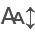

In [2]:
import os
import sqlite3
import warnings
import re
from io import StringIO

import numpy as np
import pandas as pd

from Functions import BDG2, preprocess, main

import itables.options as opt
from itables import init_notebook_mode, show
from itables.downsample import as_nbytes, nbytes
from itables.sample_dfs import get_indicators

init_notebook_mode(all_interactive=True)
# Configure global options
opt.maxBytes = "0"  # Display all rows without downsampling
opt.buttons = ["copyHtml5", "csvHtml5", "excelHtml5"]  # Add export buttons

def show_df(df):
    # Display the dataframe with SearchBuilder
    show(df, layout={"top1": "searchBuilder"}, searchBuilder={"preDefined": {}})

# Load Data

In [3]:
class DataContainer:
    """
    A container class to store and access training, validation, testing splits, and full DataFrame.
    """
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, full_data, data_type, more_info, feature_names):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.full_data = full_data
        self.data_type = data_type
        self.more_info = more_info
        self.feature_names = feature_names  # New attribute for feature names


def load_and_preprocess_data(dataset_path='./Data/', dataset_type="LondonHydro", primary_use=None, 
                             option_number=1, numerical_columns=None, categorical_columns=None, 
                             binary_columns=None, datetime_column=None, target_column=None,
                             scaled=True, scale_type='features', val_ratio=0.1, test_ratio=0.1, 
                             input_seq_length=48, output_seq_length=24):
    """
    Load and preprocess dataset based on the specified type and criteria.

    Returns:
        DataContainer: An object containing training, validation, testing splits, the full DataFrame, 
                       and feature names.
    """
    feature_names = None  # Placeholder for feature names

    if dataset_type == "LondonHydro":
        # Load LondonHydro dataset
        dataset_folder = os.path.join(dataset_path, 'LondonHydro')
        csv_files = [file for file in os.listdir(dataset_folder) if file.endswith('.csv')]
        if not csv_files:
            raise FileNotFoundError("No CSV files found in the specified dataset path.")
        df = pd.read_csv(os.path.join(dataset_folder, csv_files[option_number]))

        # Apply preprocessing
        df[target_column] = np.exp(df[target_column])
        df = preprocess.pre_process(df, numerical_columns, categorical_columns, binary_columns, datetime_column, target_column)
        df = preprocess.get_datetime_features(df, datetime_column, cos_sin=False)

        # Define feature columns
        feature_names = ["Hour", "DayOfWeek", "DayOfMonth", "Month", "DayOfYear", "IsWeekend",
                         "temperature", "humidity", "wind_speed", "energy_consumption"]
        df = df[feature_names]

        data_type = 'Residential'
        more_info = csv_files[option_number]
        
    elif dataset_type == "BDG2":
        # Load BDG2 dataset
        dataset_file = os.path.join(dataset_path, 'building-data-genome-project-2/electricity_cleaned.txt')
        df = pd.read_csv(dataset_file)
        df, more_info = BDG2.get_column_by_criteria(df, primary_use=primary_use, option_number=option_number)

        if primary_use == 'industrial':
            data_type = 'Manufacturing facility'
        elif primary_use == 'office':
            data_type = 'Office building'
        elif primary_use == 'retail':
            data_type = 'Retail store'
        elif primary_use == 'health':
            data_type = 'Medical clinic'

        # Extract feature names for BDG2
        feature_names = df.columns.tolist()

    else:
        raise ValueError("Invalid dataset_type. Choose either 'LondonHydro' or 'BDG2'.")

    # Load and preprocess data with sequences
    X_train, y_train, X_val, y_val, X_test, y_test, X, y, full_data = preprocess.load_and_preprocess_data_with_sequences(
        df, target=target_column, scaled=scaled, scale_type=scale_type,
        val_ratio=val_ratio, test_ratio=test_ratio, 
        input_seq_length=input_seq_length, output_seq_length=output_seq_length)

    # Print shapes for verification
    print("\nShapes:")
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_val:", X_val.shape)
    print("y_val:", y_val.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)

    # Wrap results in DataContainer
    return DataContainer(X_train, y_train, X_val, y_val, X_test, y_test, full_data, data_type, more_info, feature_names)


In [36]:
# #### Load and preprocess LondonHydro dataset
mydata = load_and_preprocess_data(
    dataset_path='./Data',
    dataset_type="LondonHydro",
    numerical_columns=['energy_consumption', 'temperature', 'humidity', 'wind_speed'],
    datetime_column='timestamp',
    target_column='energy_consumption',
    option_number=0,
    scaled=True, scale_type='features', val_ratio=0.1, test_ratio=0.1, 
                             input_seq_length=48, output_seq_length=24
)
# show_df(mydata.full_data)

# Load and preprocess BDG2 dataset
# industrial, office, retail, health
mydata = load_and_preprocess_data(
    dataset_path='./Data',
    dataset_type="BDG2",
    primary_use="office",
    option_number=1,
    target_column='energy_consumption',
    scaled=True, scale_type='features', val_ratio=0.1, test_ratio=0.1, 
                             input_seq_length=48, output_seq_length=24

)
# show_df(mydata.full_data)


Shapes:
X_train: (20391, 48, 10)
y_train: (20391, 24, 1)
X_val: (2548, 48, 10)
y_val: (2548, 24, 1)
X_test: (2548, 48, 10)
y_test: (2548, 24, 1)
Number of missing values before filling: 466
Number of missing values after filling: 0
Primary Use: 'office'
Building Name: 'Catherine'
SiteID: 'Panther'
Filling missing values in column 'energy_consumption' with 0.00% missing values.
Filling missing values in column 'Hour' with 0.00% missing values.
Filling missing values in column 'DayOfWeek' with 0.00% missing values.
Filling missing values in column 'DayOfMonth' with 0.00% missing values.
Filling missing values in column 'Month' with 0.00% missing values.
Filling missing values in column 'DayOfYear' with 0.00% missing values.
Filling missing values in column 'IsWeekend' with 0.00% missing values.
Filling missing values in column 'airTemperature' with 0.00% missing values.
Filling missing values in column 'dewTemperature' with 0.00% missing values.
Filling missing values in column 'seaLvlP

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


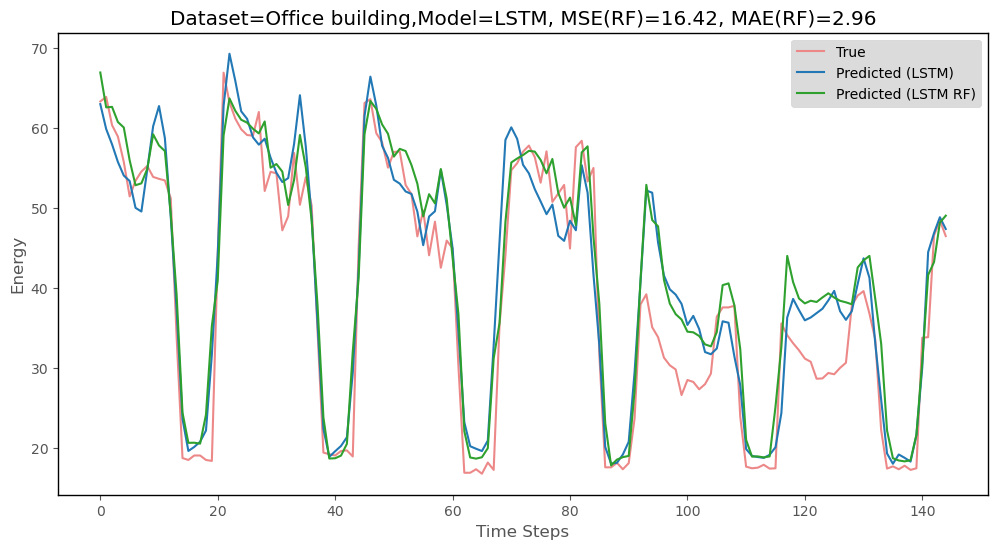

Plot saved at ./Results/Plots/Office building/LSTM_ComparisonPlot.pdf


In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.ensemble import RandomForestRegressor
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

def load_and_plot_models(mydata, model_type):

    # Unpack the data
    X_train = mydata.X_train 
    y_train = mydata.y_train 
    X_val = mydata.X_val 
    y_val = mydata.y_val 
    X_test = mydata.X_test 
    y_test = mydata.y_test 

    df_name = mydata.data_type
    # Directories for loading models
    model_dir = f"./Results/Models/{df_name}"

    # Load the deep learning model
    dl_model_path = f"{model_dir}/{model_type}.keras"
    if not os.path.exists(dl_model_path):
        raise FileNotFoundError(f"Deep Learning model file not found at {dl_model_path}")
    dl_model = load_model(dl_model_path)

    # Load the corresponding random forest model
    rf_model_path = f"{model_dir}/{model_type}_RandomForest.pkl"
    if not os.path.exists(rf_model_path):
        raise FileNotFoundError(f"Random Forest model file not found at {rf_model_path}")
    rf_model = joblib.load(rf_model_path)

    # Predictions
    y_test_dl_pred = dl_model.predict(X_test)[:, 0].flatten()
    X_test_reshaped = X_test.reshape(X_test.shape[0], -1)
    y_test_rf_pred = rf_model.predict(X_test_reshaped).flatten()
    y_test_actual = y_test[:, 0].flatten()

    # Calculate metrics for each model
    def calculate_metrics(y_true, y_pred):
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        r2 = r2_score(y_true, y_pred)
        return mse, rmse, mae, mape, r2

    dl_metrics = calculate_metrics(y_test_actual, y_test_dl_pred)
    rf_metrics = calculate_metrics(y_test_dl_pred, y_test_rf_pred)

    # Plot the results
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Plot actual, DL predictions, and RF predictions
    plt.plot(
        y_test_actual[:len(y_test_actual)//10], 
        label='True', color='#ed8787', alpha=0.99
    )
    plt.plot(
        y_test_dl_pred[:len(y_test_dl_pred)//10], 
        label=f'Predicted ({model_type})', color='#1f77b4', alpha=0.99
    )
    plt.plot(
        y_test_rf_pred[:len(y_test_rf_pred)//10], 
        label=f'Predicted ({model_type} RF)', color='#2ca02c', alpha=0.99
    )

    # Set title and labels
    plt.title(f'Dataset={mydata.data_type}, Model={model_type}, MSE(RF)={rf_metrics[0]:.2f}, MAE(RF)={rf_metrics[2]:.2f}')
    plt.xlabel('Time Steps')
    plt.ylabel('Energy')

    # Add border lines (spines)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    # Set legend
    legend = plt.legend(loc='upper right')
    legend.get_frame().set_facecolor('lightgray')

    # Save and show the plot
    plot_dir = f"./Results/Plots/{df_name}"
    os.makedirs(plot_dir, exist_ok=True)
    plot_path = f"{plot_dir}/{model_type}_ComparisonPlot.pdf"
    plt.savefig(plot_path, format='pdf', facecolor='white', bbox_inches='tight')
    plt.show()

    # Explicitly close the plot
    plt.close()

    print(f"Plot saved at {plot_path}")

load_and_plot_models(mydata=mydata, model_type='LSTM')

# Prediction Models

[I 2025-01-05 19:30:44,739] A new study created in memory with name: no-name-c24044f7-3261-4032-bccb-e666084bc7c3
[I 2025-01-05 19:34:22,702] Trial 0 finished with value: 40.836341857910156 and parameters: {'lstm_units': 119, 'dropout_rate': 0.2671677925626608, 'num_lstm_layers': 2, 'learning_rate': 0.0005011244076857183}. Best is trial 0 with value: 40.836341857910156.
[I 2025-01-05 19:35:51,594] Trial 1 finished with value: 45.76039505004883 and parameters: {'lstm_units': 102, 'dropout_rate': 0.29449749897733035, 'num_lstm_layers': 1, 'learning_rate': 0.0005186801409359625}. Best is trial 0 with value: 40.836341857910156.
[I 2025-01-05 19:37:52,516] Trial 2 finished with value: 48.647212982177734 and parameters: {'lstm_units': 109, 'dropout_rate': 0.28720279875173893, 'num_lstm_layers': 1, 'learning_rate': 0.0001372575778760468}. Best is trial 0 with value: 40.836341857910156.
[I 2025-01-05 19:38:54,922] Trial 3 finished with value: 49.25911331176758 and parameters: {'lstm_units': 10

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


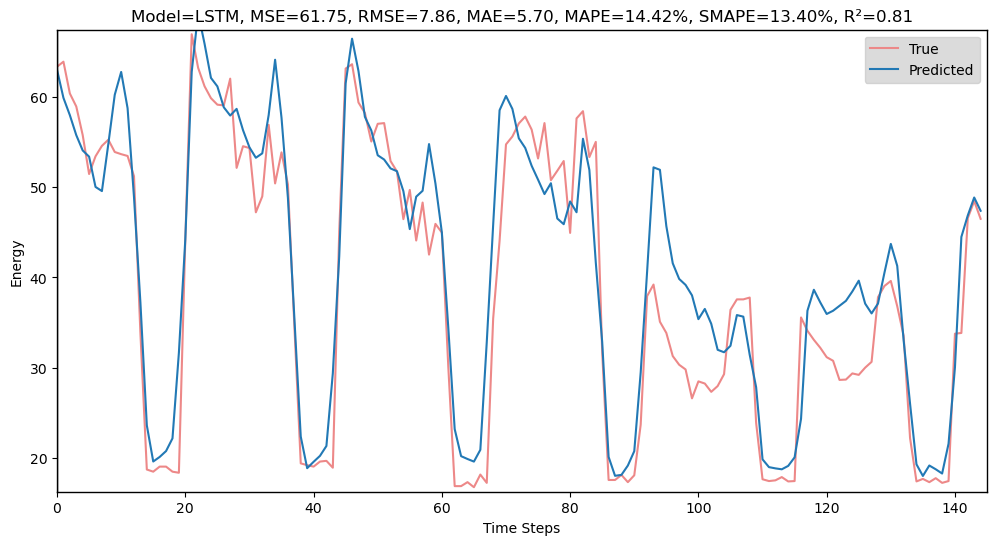

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


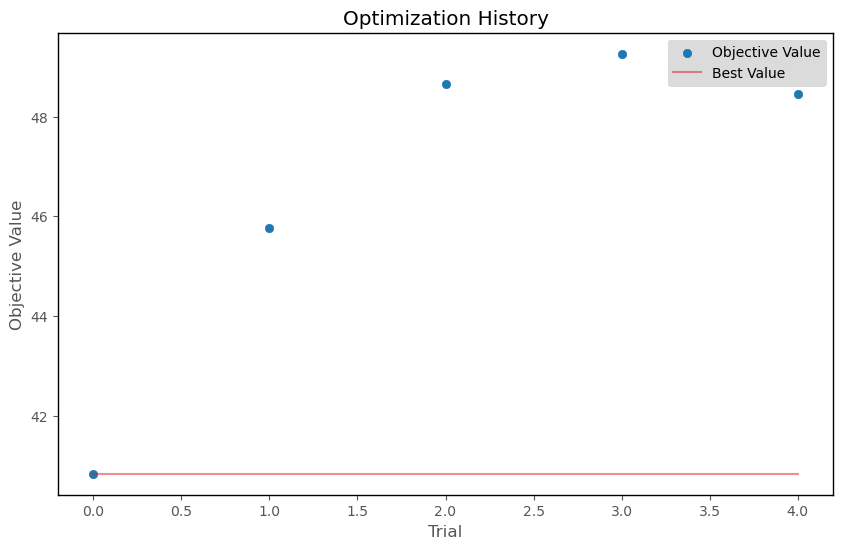

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


[I 2025-01-05 19:45:47,862] A new study created in memory with name: no-name-4e1ed364-6405-4249-a503-51070489f87c
[I 2025-01-05 19:50:00,678] Trial 0 finished with value: 56.789051985666575 and parameters: {'n_estimators': 96, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 7}. Best is trial 0 with value: 56.789051985666575.
[I 2025-01-05 19:50:20,924] Trial 3 finished with value: 48.600201618208736 and parameters: {'n_estimators': 52, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 7}. Best is trial 3 with value: 48.600201618208736.
[I 2025-01-05 19:51:36,052] Trial 1 finished with value: 48.31229505391258 and parameters: {'n_estimators': 66, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 6}. Best is trial 1 with value: 48.31229505391258.
[I 2025-01-05 19:54:14,845] Trial 4 finished with value: 49.78358976464922 and parameters: {'n_estimators': 90, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 1 with value: 48.31

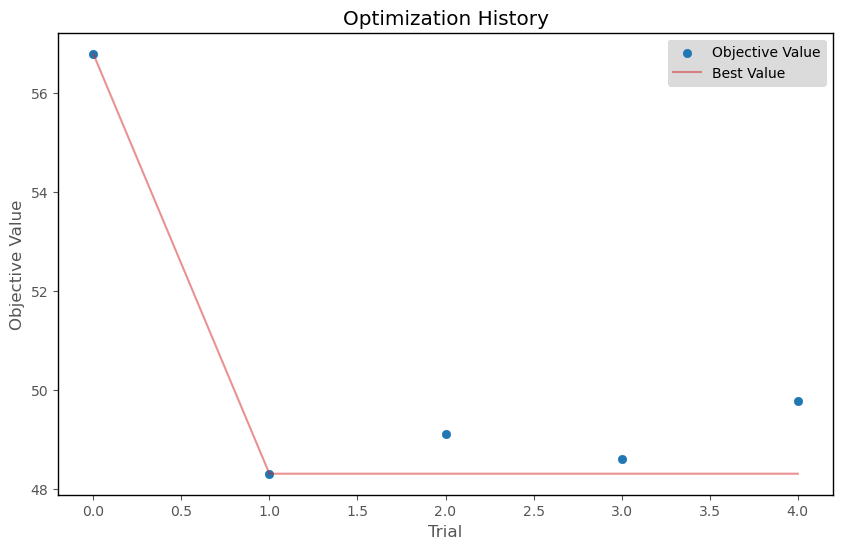

[I 2025-01-05 19:56:39,311] A new study created in memory with name: no-name-1de18c66-cd31-4d50-b605-959596ddc6e8
[I 2025-01-05 20:02:38,562] Trial 0 finished with value: 42.78409957885742 and parameters: {'gru_units': 107, 'dropout_rate': 0.2659153483009348, 'num_gru_layers': 2, 'learning_rate': 0.0003072751436208576}. Best is trial 0 with value: 42.78409957885742.
[I 2025-01-05 20:06:15,342] Trial 1 finished with value: 38.7181282043457 and parameters: {'gru_units': 113, 'dropout_rate': 0.27266716899685906, 'num_gru_layers': 2, 'learning_rate': 0.0008923804367096194}. Best is trial 1 with value: 38.7181282043457.
[I 2025-01-05 20:12:34,857] Trial 2 finished with value: 47.79864501953125 and parameters: {'gru_units': 103, 'dropout_rate': 0.2539530807093724, 'num_gru_layers': 2, 'learning_rate': 0.0001576348911953196}. Best is trial 1 with value: 38.7181282043457.
[I 2025-01-05 20:15:50,840] Trial 3 finished with value: 41.418914794921875 and parameters: {'gru_units': 120, 'dropout_rat

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


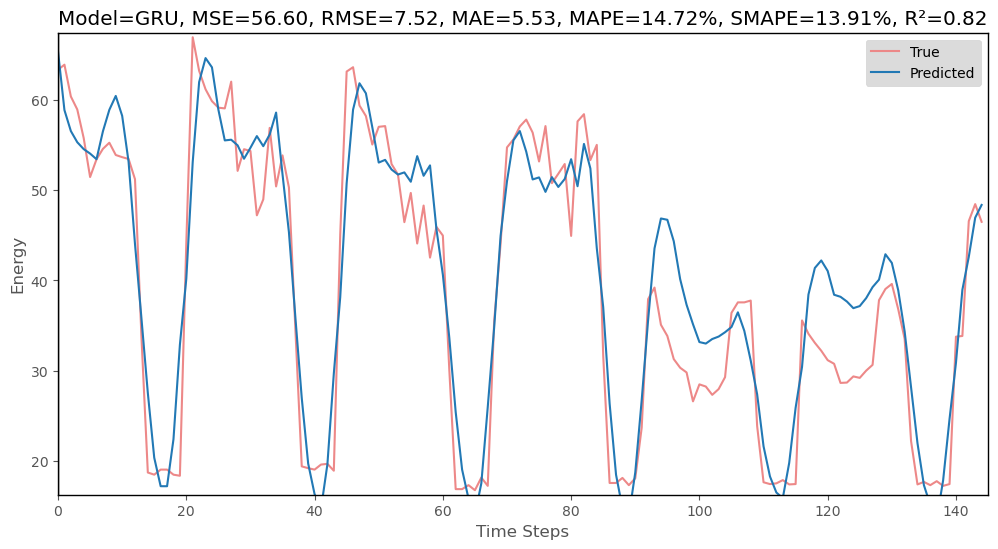

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


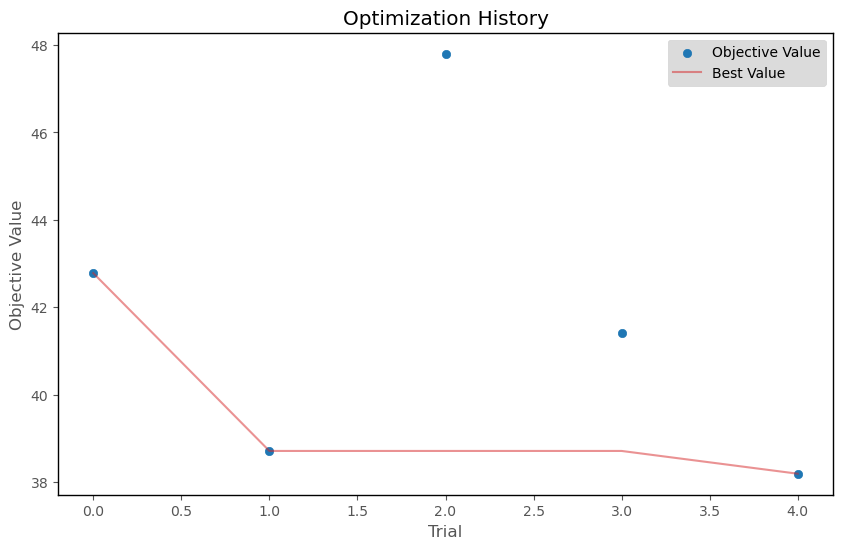

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


[I 2025-01-05 20:29:43,112] A new study created in memory with name: no-name-57109f6c-ee15-4d3b-87a4-2a8b0eb09332
[I 2025-01-05 20:31:45,285] Trial 3 finished with value: 32.54375063138393 and parameters: {'n_estimators': 19, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 10}. Best is trial 3 with value: 32.54375063138393.
[I 2025-01-05 20:33:05,343] Trial 2 finished with value: 33.02446819325336 and parameters: {'n_estimators': 24, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 7}. Best is trial 3 with value: 32.54375063138393.
[I 2025-01-05 20:39:35,985] Trial 1 finished with value: 35.318784118658456 and parameters: {'n_estimators': 61, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 3 with value: 32.54375063138393.
[I 2025-01-05 20:41:07,531] Trial 4 finished with value: 35.739531206290735 and parameters: {'n_estimators': 64, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 3 with value: 32.5437

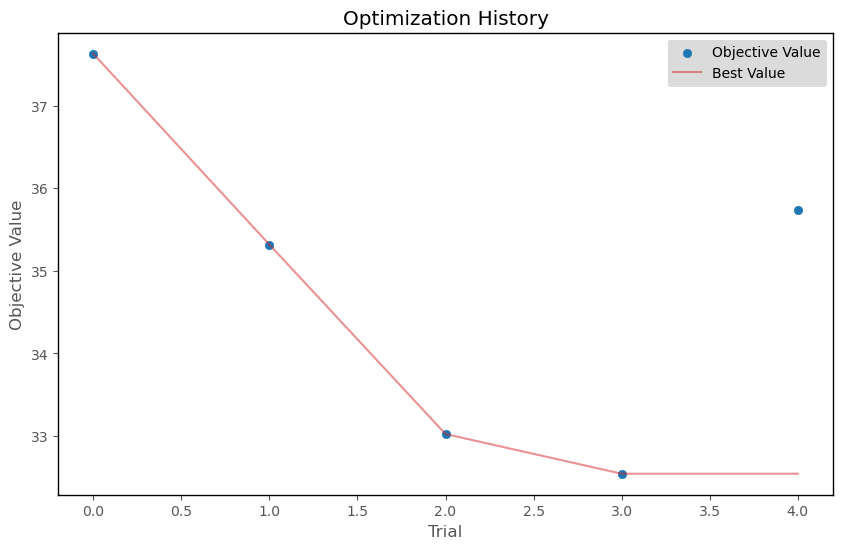

[I 2025-01-05 20:46:04,375] A new study created in memory with name: no-name-801f131c-1b54-4b19-81ba-c50f2a13706a
[I 2025-01-05 20:49:15,201] Trial 0 finished with value: 40.57504653930664 and parameters: {'lstm_units': 108, 'dropout_rate': 0.2594092145959538, 'num_lstm_layers': 2, 'learning_rate': 0.0007764324455678146}. Best is trial 0 with value: 40.57504653930664.
[I 2025-01-05 20:51:29,075] Trial 1 finished with value: 39.19883728027344 and parameters: {'lstm_units': 84, 'dropout_rate': 0.27722686414755066, 'num_lstm_layers': 2, 'learning_rate': 0.0007642442228196103}. Best is trial 1 with value: 39.19883728027344.
[I 2025-01-05 20:52:56,896] Trial 2 finished with value: 37.032283782958984 and parameters: {'lstm_units': 103, 'dropout_rate': 0.21386177854076846, 'num_lstm_layers': 1, 'learning_rate': 0.000984612997357257}. Best is trial 2 with value: 37.032283782958984.
[I 2025-01-05 20:55:58,131] Trial 3 finished with value: 39.364871978759766 and parameters: {'lstm_units': 109, '

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


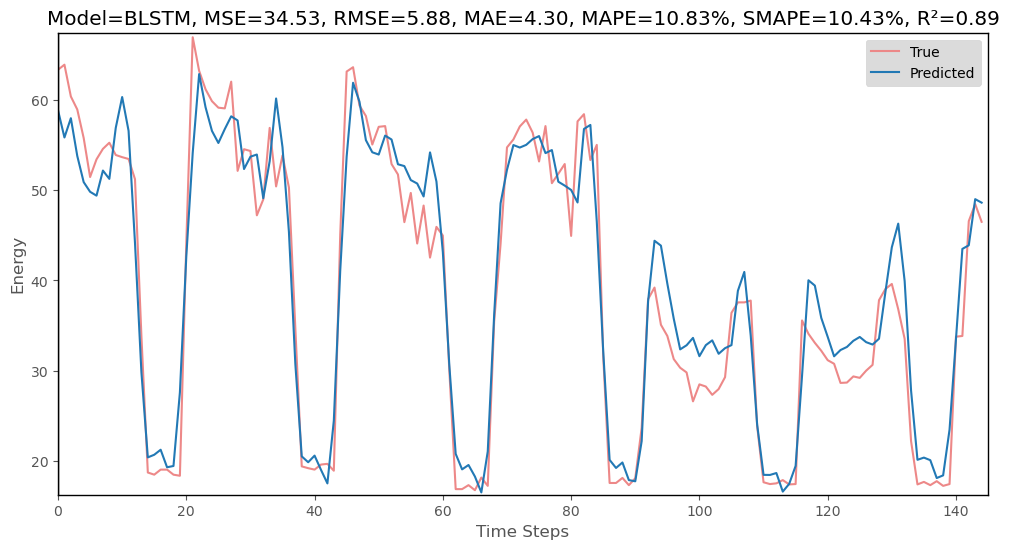

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


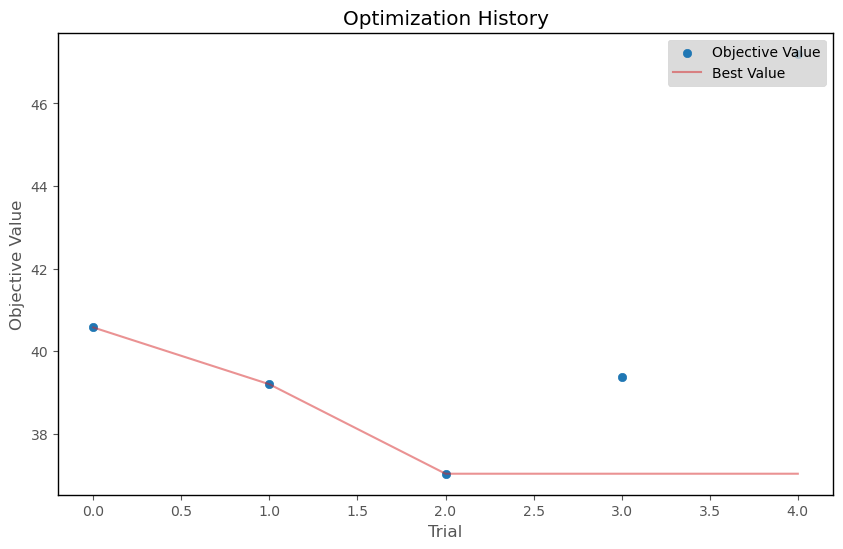

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


[I 2025-01-05 21:00:36,799] A new study created in memory with name: no-name-1f8b93ee-211a-49b2-9e19-7623f03aada2
[I 2025-01-05 21:06:06,758] Trial 2 finished with value: 48.238631179854636 and parameters: {'n_estimators': 98, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 8}. Best is trial 2 with value: 48.238631179854636.
[I 2025-01-05 21:07:55,088] Trial 4 finished with value: 21.814281085944707 and parameters: {'n_estimators': 43, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 4 with value: 21.814281085944707.
[I 2025-01-05 21:08:22,181] Trial 3 finished with value: 22.910158332592264 and parameters: {'n_estimators': 58, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 4 with value: 21.814281085944707.
[I 2025-01-05 21:10:55,265] Trial 1 finished with value: 19.82965365373294 and parameters: {'n_estimators': 72, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 10}. Best is trial 1 with value: 19.

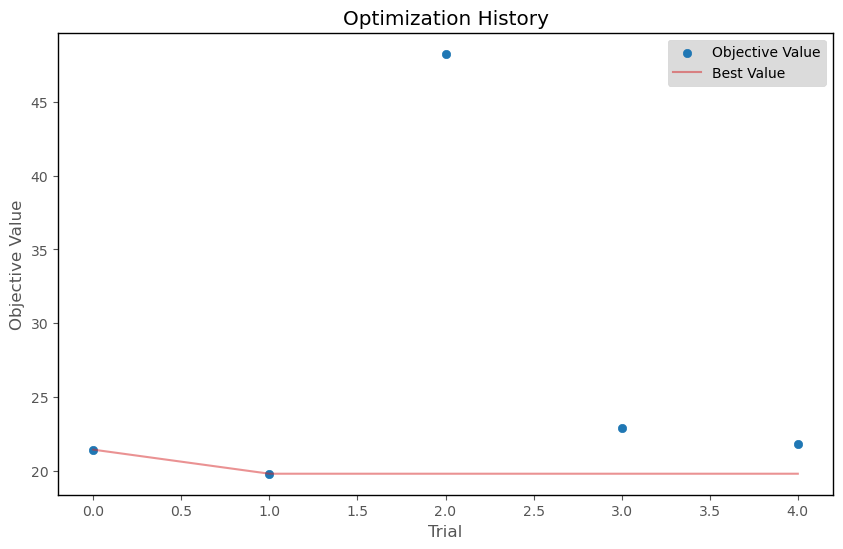

[I 2025-01-05 21:14:52,427] A new study created in memory with name: no-name-fe868ca1-4da0-432d-962b-fc38d4bdb7d0
[I 2025-01-05 21:17:33,281] Trial 0 finished with value: 39.268123626708984 and parameters: {'gru_units': 118, 'dropout_rate': 0.26034034528176575, 'num_gru_layers': 1, 'learning_rate': 0.0003151197260820526}. Best is trial 0 with value: 39.268123626708984.
[I 2025-01-05 21:22:01,983] Trial 1 finished with value: 38.03590393066406 and parameters: {'gru_units': 64, 'dropout_rate': 0.24582235699397706, 'num_gru_layers': 2, 'learning_rate': 0.0009356422176629031}. Best is trial 1 with value: 38.03590393066406.
[I 2025-01-05 21:23:56,588] Trial 2 finished with value: 46.55726623535156 and parameters: {'gru_units': 97, 'dropout_rate': 0.29219720732479926, 'num_gru_layers': 1, 'learning_rate': 0.0008667367700176309}. Best is trial 1 with value: 38.03590393066406.
[I 2025-01-05 21:26:52,975] Trial 3 finished with value: 42.65879440307617 and parameters: {'gru_units': 77, 'dropout_

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


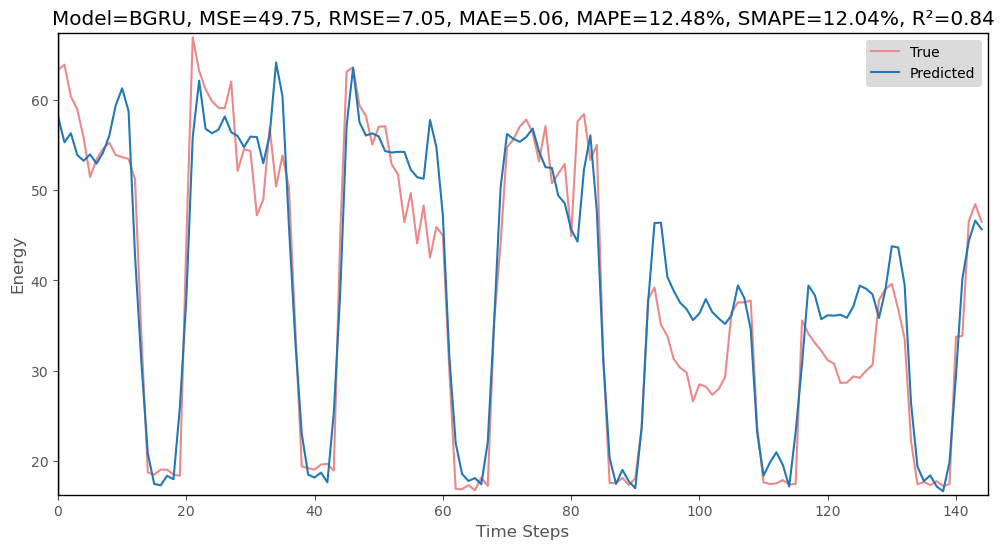

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


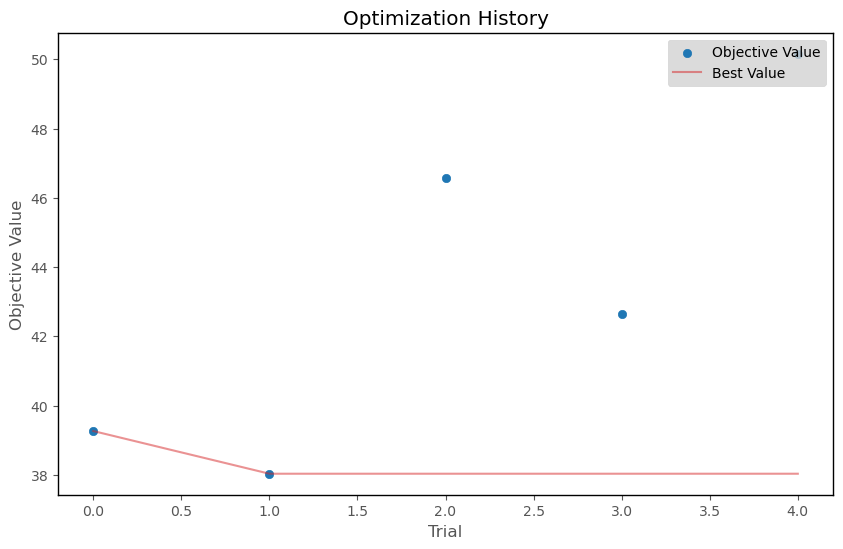

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


[I 2025-01-05 21:33:24,526] A new study created in memory with name: no-name-1c371b32-3424-45be-8f17-3079f2f31085
[I 2025-01-05 21:35:19,682] Trial 2 finished with value: 72.17712025679887 and parameters: {'n_estimators': 17, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 10}. Best is trial 2 with value: 72.17712025679887.
[I 2025-01-05 21:35:27,060] Trial 4 finished with value: 72.799273757581 and parameters: {'n_estimators': 28, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 2 with value: 72.17712025679887.
[I 2025-01-05 21:40:47,223] Trial 3 finished with value: 65.98232740966492 and parameters: {'n_estimators': 68, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 9}. Best is trial 3 with value: 65.98232740966492.
[I 2025-01-05 21:42:16,982] Trial 1 finished with value: 66.93641738790747 and parameters: {'n_estimators': 84, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 9}. Best is trial 3 with value: 65.98232740

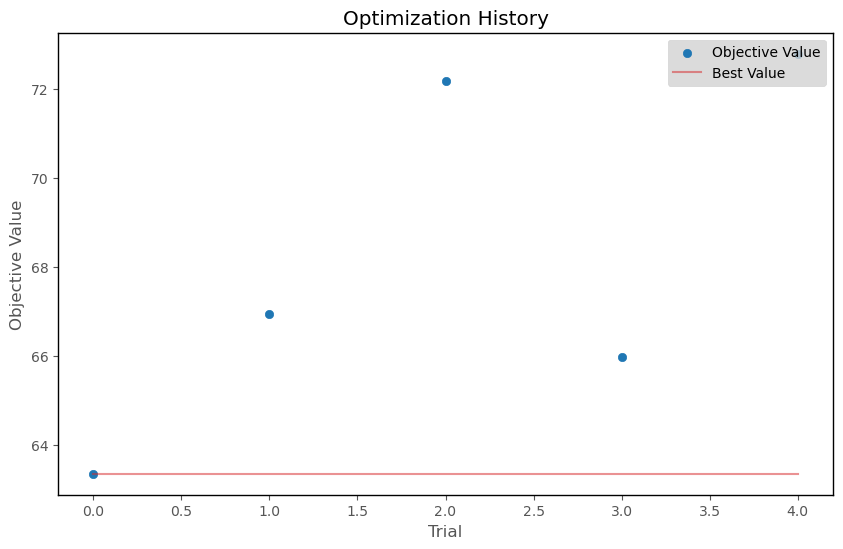

[I 2025-01-05 21:44:42,070] A new study created in memory with name: no-name-5730b004-1cb2-45a3-8fb5-abcd1f063738
[I 2025-01-05 21:44:59,684] Trial 0 finished with value: 36.271244049072266 and parameters: {'filters': 60, 'kernel_size': 5, 'dropout_rate': 0.14580031218484776, 'num_conv_layers': 2, 'optimizer': 'adam', 'l2_reg': 0.00026008459852173933}. Best is trial 0 with value: 36.271244049072266.
[I 2025-01-05 21:45:36,804] Trial 1 finished with value: 48.0283088684082 and parameters: {'filters': 85, 'kernel_size': 2, 'dropout_rate': 0.3982587232072141, 'num_conv_layers': 3, 'optimizer': 'adam', 'l2_reg': 1.1925547964048184e-06}. Best is trial 0 with value: 36.271244049072266.
[I 2025-01-05 21:45:48,599] Trial 2 finished with value: 45.77980422973633 and parameters: {'filters': 67, 'kernel_size': 5, 'dropout_rate': 0.30036423096059767, 'num_conv_layers': 3, 'optimizer': 'adam', 'l2_reg': 0.00019284921346854502}. Best is trial 0 with value: 36.271244049072266.
[I 2025-01-05 21:46:04,

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


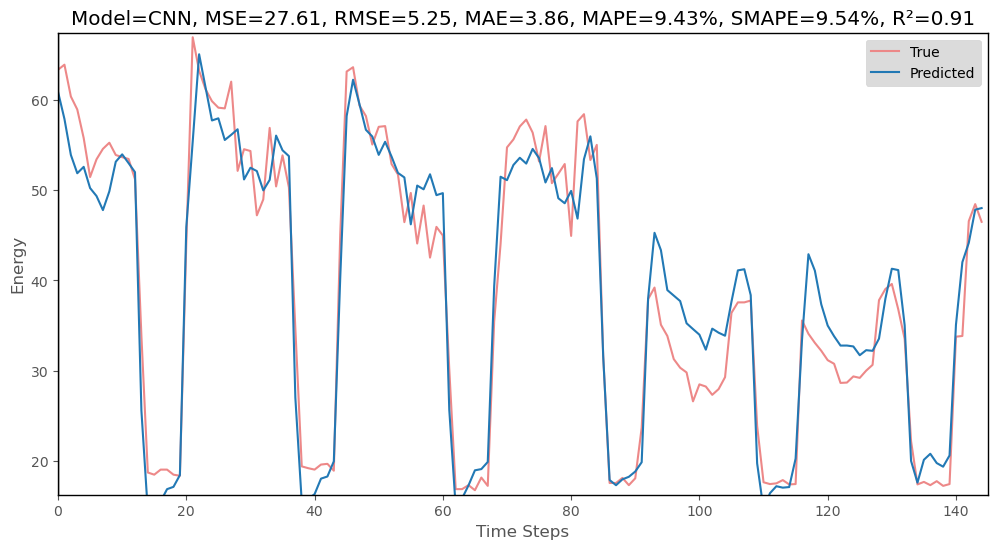

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


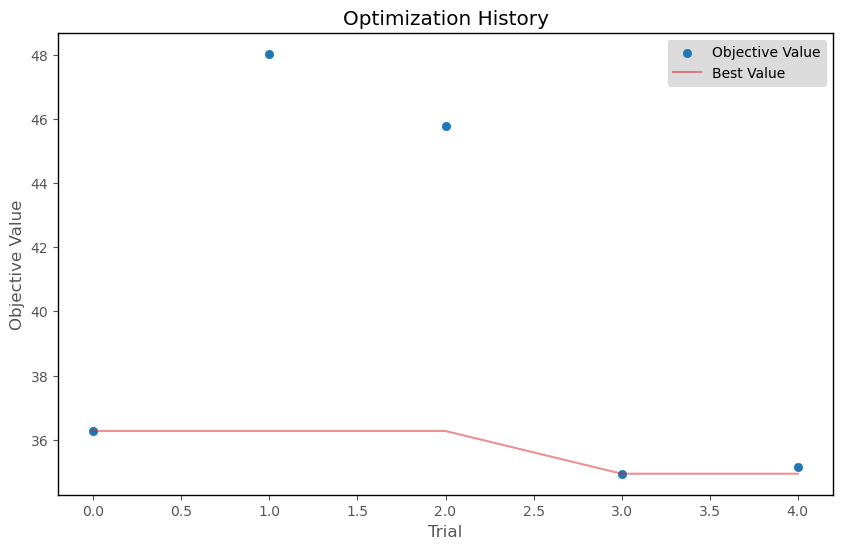

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step


[I 2025-01-05 21:46:40,147] A new study created in memory with name: no-name-4f99b296-9393-43bb-9147-0ea12e193a5b
[I 2025-01-05 21:48:32,907] Trial 3 finished with value: 42.478438874109045 and parameters: {'n_estimators': 37, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 9}. Best is trial 3 with value: 42.478438874109045.
[I 2025-01-05 21:49:41,505] Trial 4 finished with value: 29.27500312837364 and parameters: {'n_estimators': 26, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 7}. Best is trial 4 with value: 29.27500312837364.
[I 2025-01-05 21:49:54,938] Trial 1 finished with value: 56.75889456662136 and parameters: {'n_estimators': 81, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 8}. Best is trial 4 with value: 29.27500312837364.
[I 2025-01-05 21:49:55,346] Trial 2 finished with value: 34.95334608200555 and parameters: {'n_estimators': 47, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 9}. Best is trial 4 with value: 29.275003

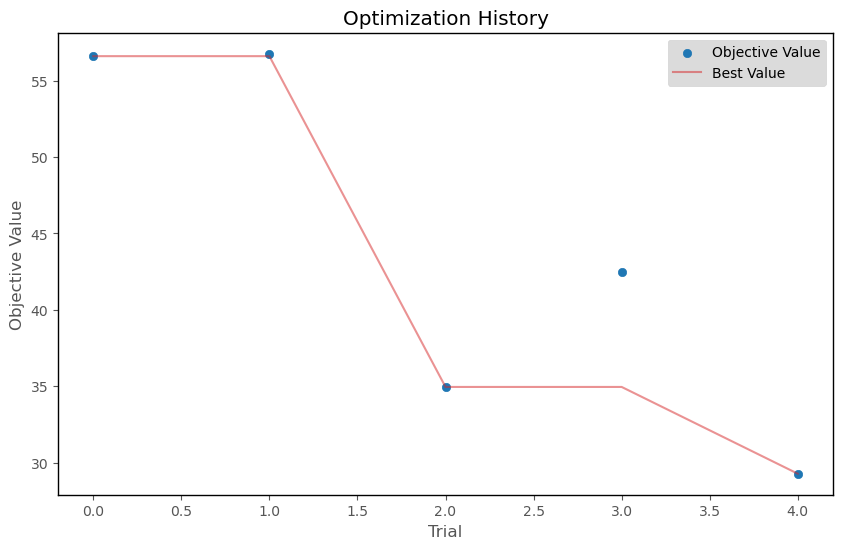

[I 2025-01-05 21:51:08,351] A new study created in memory with name: no-name-cc8d03b7-7d55-4c43-b30d-381d865698da
[I 2025-01-05 21:51:43,471] Trial 0 finished with value: 36.1722297668457 and parameters: {'filters': 52, 'kernel_size': 3, 'dropout_rate': 0.13309547938228064, 'num_tcn_blocks': 3, 'dilation_base': 4, 'l2_reg': 4.252999512217738e-06, 'optimizer': 'adam'}. Best is trial 0 with value: 36.1722297668457.
[I 2025-01-05 21:52:06,035] Trial 1 finished with value: 35.07872772216797 and parameters: {'filters': 122, 'kernel_size': 2, 'dropout_rate': 0.3632320687816353, 'num_tcn_blocks': 2, 'dilation_base': 2, 'l2_reg': 0.0005945156943812718, 'optimizer': 'adam'}. Best is trial 1 with value: 35.07872772216797.
[I 2025-01-05 21:52:55,604] Trial 2 finished with value: 33.92589569091797 and parameters: {'filters': 104, 'kernel_size': 4, 'dropout_rate': 0.2494414877395804, 'num_tcn_blocks': 3, 'dilation_base': 4, 'l2_reg': 8.573669575351496e-05, 'optimizer': 'rmsprop'}. Best is trial 2 w

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


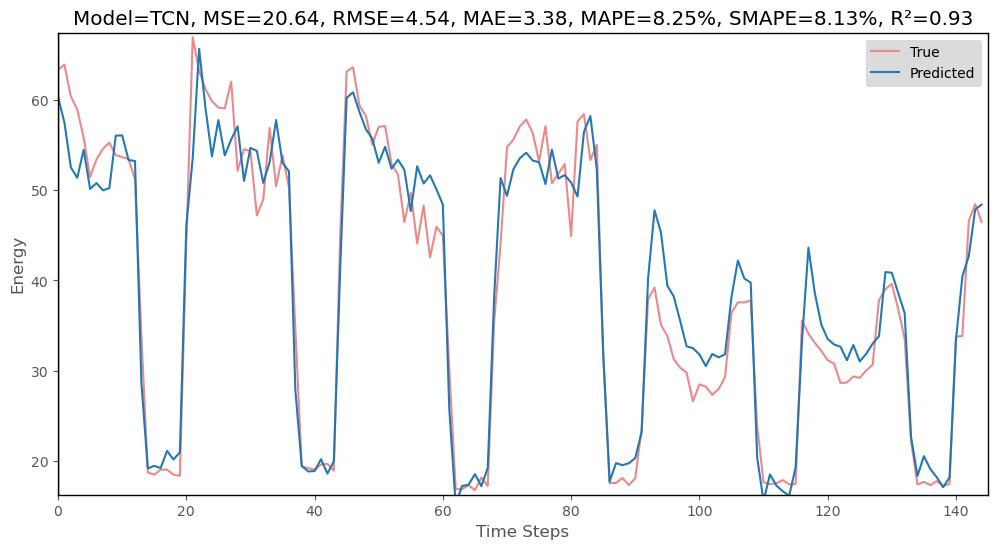

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


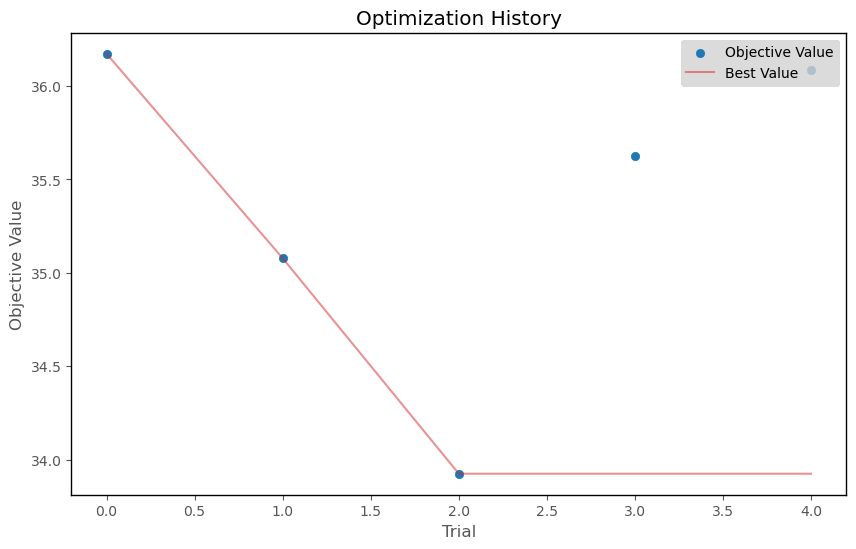

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


[I 2025-01-05 21:55:01,818] A new study created in memory with name: no-name-85c635b0-4655-49b9-b625-25ff100e9969
[I 2025-01-05 21:55:37,667] Trial 2 finished with value: 27.48859473424785 and parameters: {'n_estimators': 13, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 2 with value: 27.48859473424785.
[I 2025-01-05 21:56:40,299] Trial 4 finished with value: 27.18011617442042 and parameters: {'n_estimators': 38, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 4 with value: 27.18011617442042.
[I 2025-01-05 21:58:20,189] Trial 3 finished with value: 12.871677714418727 and parameters: {'n_estimators': 31, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 3 with value: 12.871677714418727.
[I 2025-01-05 21:59:29,248] Trial 0 finished with value: 19.46833451170874 and parameters: {'n_estimators': 90, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 10}. Best is trial 3 with value: 12.871677

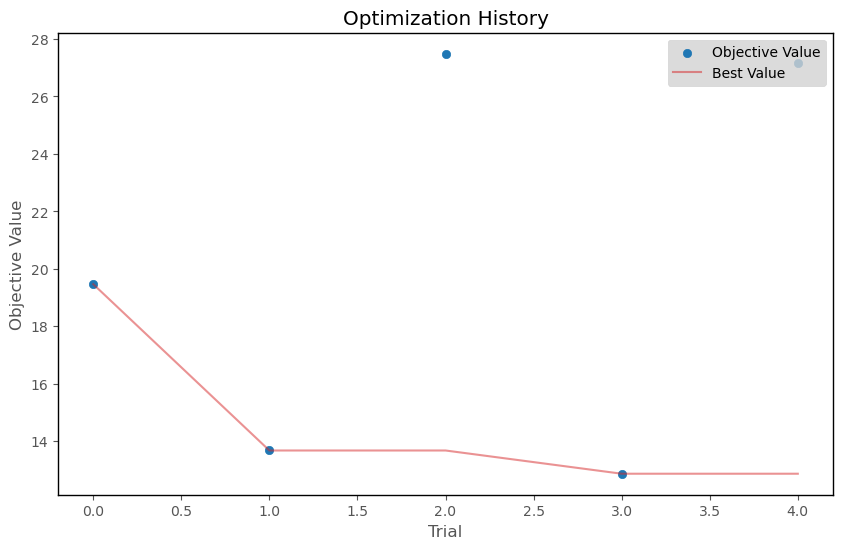

[I 2025-01-05 22:07:41,380] A new study created in memory with name: no-name-3c1a4f56-b6aa-4e70-a66a-23f634182f8a
[I 2025-01-05 22:07:52,201] Trial 0 finished with value: 94.46466064453125 and parameters: {'filters': 107, 'kernel_size': 2, 'dilation_rate': 1, 'dropout_rate': 0.27230554782061767, 'num_conv_layers': 3, 'optimizer': 'rmsprop', 'l2_reg': 7.52556068805578e-05}. Best is trial 0 with value: 94.46466064453125.
[I 2025-01-05 22:08:03,766] Trial 1 finished with value: 48.19183349609375 and parameters: {'filters': 61, 'kernel_size': 2, 'dilation_rate': 4, 'dropout_rate': 0.24286652555706706, 'num_conv_layers': 2, 'optimizer': 'adam', 'l2_reg': 0.00010923970590202896}. Best is trial 1 with value: 48.19183349609375.
[I 2025-01-05 22:08:46,080] Trial 2 finished with value: 43.51494216918945 and parameters: {'filters': 42, 'kernel_size': 2, 'dilation_rate': 2, 'dropout_rate': 0.30835685949689867, 'num_conv_layers': 3, 'optimizer': 'adam', 'l2_reg': 4.715190436215305e-05}. Best is tri

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


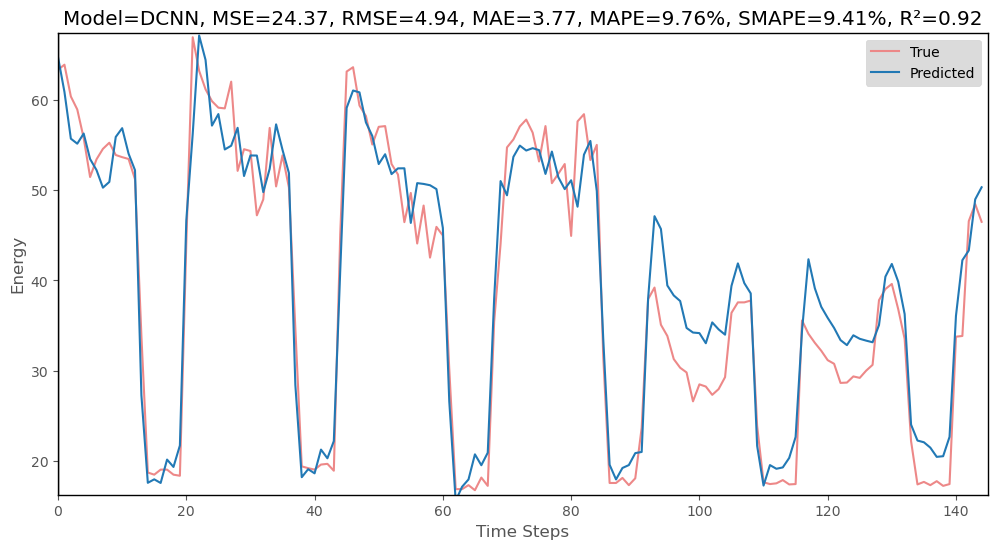

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


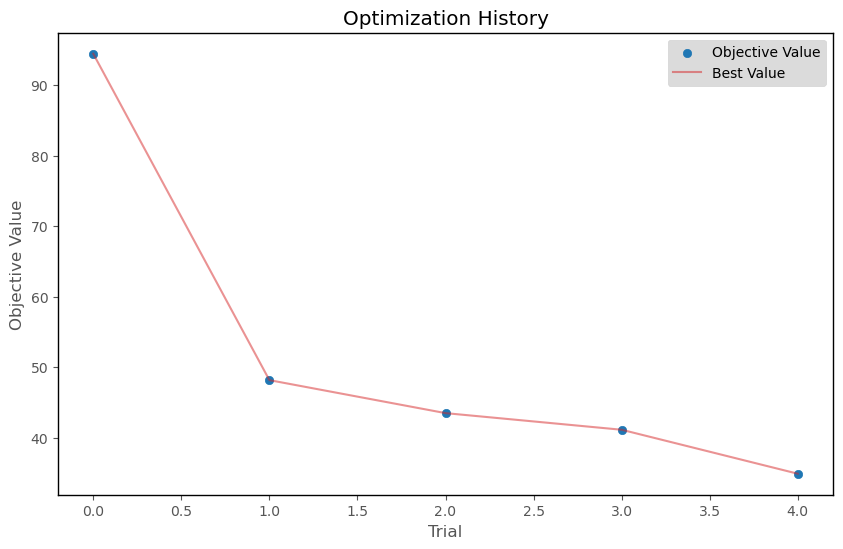

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step


[I 2025-01-05 22:09:41,059] A new study created in memory with name: no-name-3db6fca6-9f6e-4948-944c-327c85bd020b
[I 2025-01-05 22:11:54,504] Trial 3 finished with value: 15.204803678967357 and parameters: {'n_estimators': 37, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 3 with value: 15.204803678967357.
[I 2025-01-05 22:12:24,193] Trial 4 finished with value: 13.369894694541363 and parameters: {'n_estimators': 40, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 6}. Best is trial 4 with value: 13.369894694541363.
[I 2025-01-05 22:17:43,000] Trial 0 finished with value: 10.56321634566751 and parameters: {'n_estimators': 78, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 0 with value: 10.56321634566751.
[I 2025-01-05 22:18:47,343] Trial 1 finished with value: 10.694227959063962 and parameters: {'n_estimators': 99, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 6}. Best is trial 0 with value: 10.563

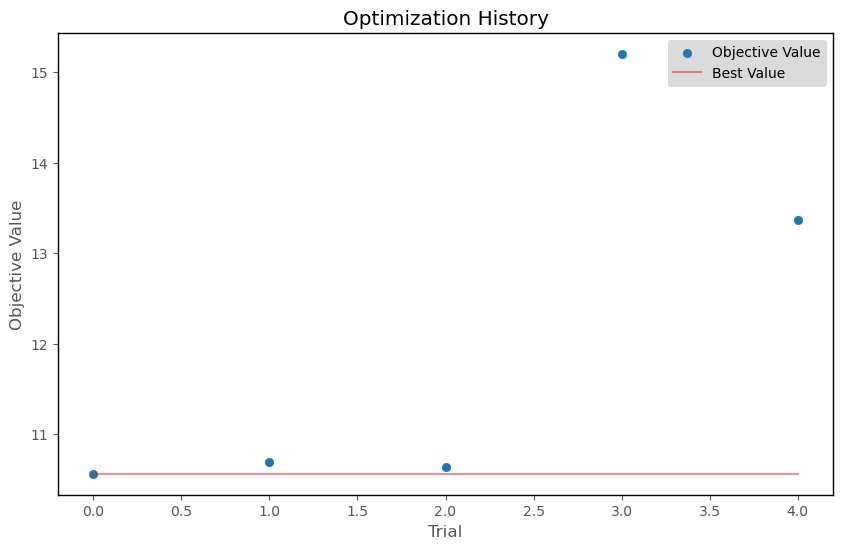

[I 2025-01-05 22:21:35,012] A new study created in memory with name: no-name-9e793926-23ea-4469-8c09-4544f6e506da
[I 2025-01-05 22:22:06,195] Trial 0 finished with value: 36.682430267333984 and parameters: {'filters': 85, 'kernel_size': 3, 'dilation_rate': 1, 'num_wavenet_blocks': 3, 'dropout_rate': 0.19079845731582695, 'l2_reg': 0.0009548250945139145, 'optimizer': 'adam'}. Best is trial 0 with value: 36.682430267333984.
[I 2025-01-05 22:22:17,567] Trial 1 finished with value: 37.648780822753906 and parameters: {'filters': 81, 'kernel_size': 5, 'dilation_rate': 2, 'num_wavenet_blocks': 1, 'dropout_rate': 0.29469318573068604, 'l2_reg': 1.2576511727112165e-06, 'optimizer': 'rmsprop'}. Best is trial 0 with value: 36.682430267333984.
[I 2025-01-05 22:22:36,487] Trial 2 finished with value: 36.03970718383789 and parameters: {'filters': 120, 'kernel_size': 5, 'dilation_rate': 4, 'num_wavenet_blocks': 1, 'dropout_rate': 0.18436934309131608, 'l2_reg': 2.1834028216137e-06, 'optimizer': 'rmsprop

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


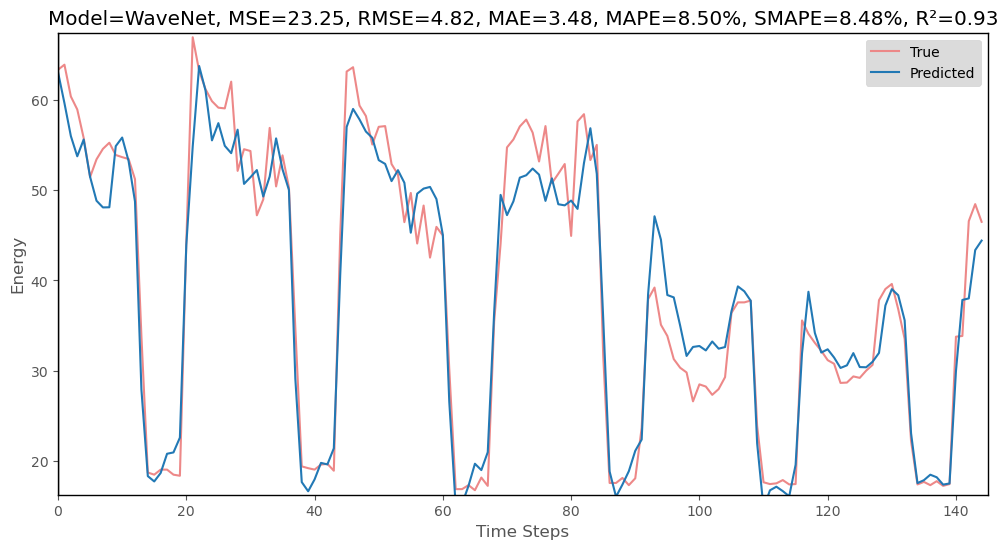

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


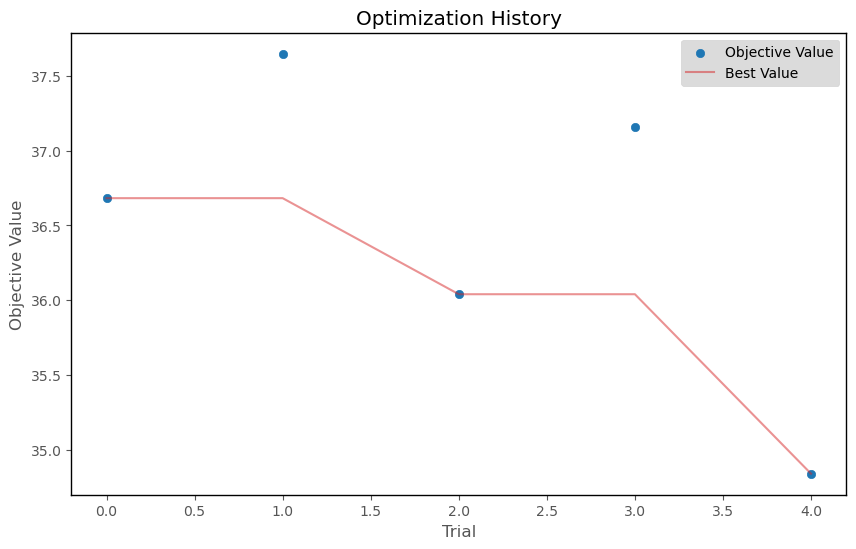

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


[I 2025-01-05 22:23:30,698] A new study created in memory with name: no-name-1e6babf2-96b1-4c2e-90bd-7d6a2cf075d3
[I 2025-01-05 22:26:48,906] Trial 3 finished with value: 59.83675908548658 and parameters: {'n_estimators': 90, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 5}. Best is trial 3 with value: 59.83675908548658.
[I 2025-01-05 22:27:57,101] Trial 1 finished with value: 12.269581253624976 and parameters: {'n_estimators': 34, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 9}. Best is trial 1 with value: 12.269581253624976.
[I 2025-01-05 22:29:36,302] Trial 4 finished with value: 10.526047435710502 and parameters: {'n_estimators': 40, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 4 with value: 10.526047435710502.
[I 2025-01-05 22:36:22,615] Trial 2 finished with value: 10.817834478367054 and parameters: {'n_estimators': 89, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 4 with value: 10.52

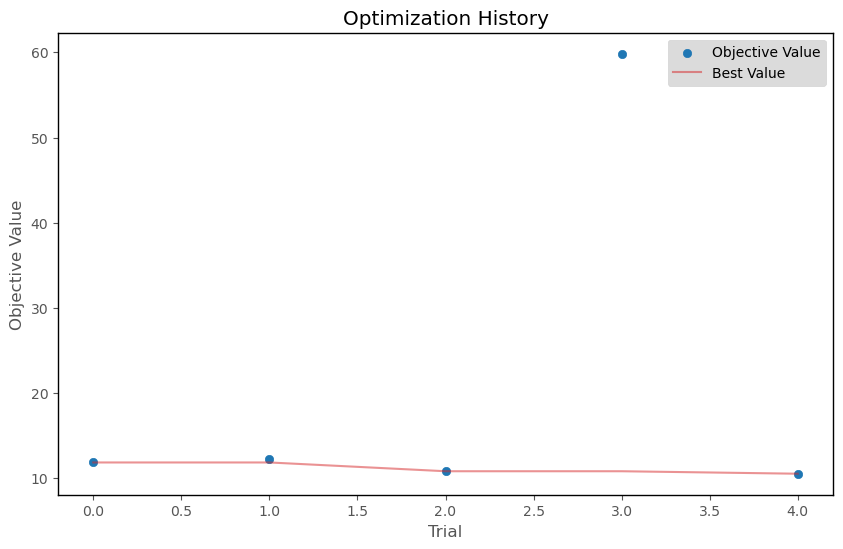

[I 2025-01-05 22:38:45,238] A new study created in memory with name: no-name-0b304615-1189-469c-a7ad-faa6c174e3d8
[I 2025-01-05 22:42:56,593] Trial 0 finished with value: 39.77867889404297 and parameters: {'hidden_units': 132, 'dropout_rate': 0.3725702597535463, 'num_lstm_layers': 2, 'num_heads': 4, 'num_attention_blocks': 2, 'l2_reg': 0.0009084578698059952, 'learning_rate': 0.000312412080543982, 'optimizer': 'adam'}. Best is trial 0 with value: 39.77867889404297.
[I 2025-01-05 22:52:01,586] Trial 1 finished with value: 39.36528015136719 and parameters: {'hidden_units': 208, 'dropout_rate': 0.1973347332422244, 'num_lstm_layers': 1, 'num_heads': 2, 'num_attention_blocks': 4, 'l2_reg': 2.2114188331969596e-05, 'learning_rate': 0.0006904747986084732, 'optimizer': 'adam'}. Best is trial 1 with value: 39.36528015136719.
[I 2025-01-05 22:58:34,265] Trial 2 finished with value: 45.7236213684082 and parameters: {'hidden_units': 168, 'dropout_rate': 0.27603518974565844, 'num_lstm_layers': 1, 'nu

46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step


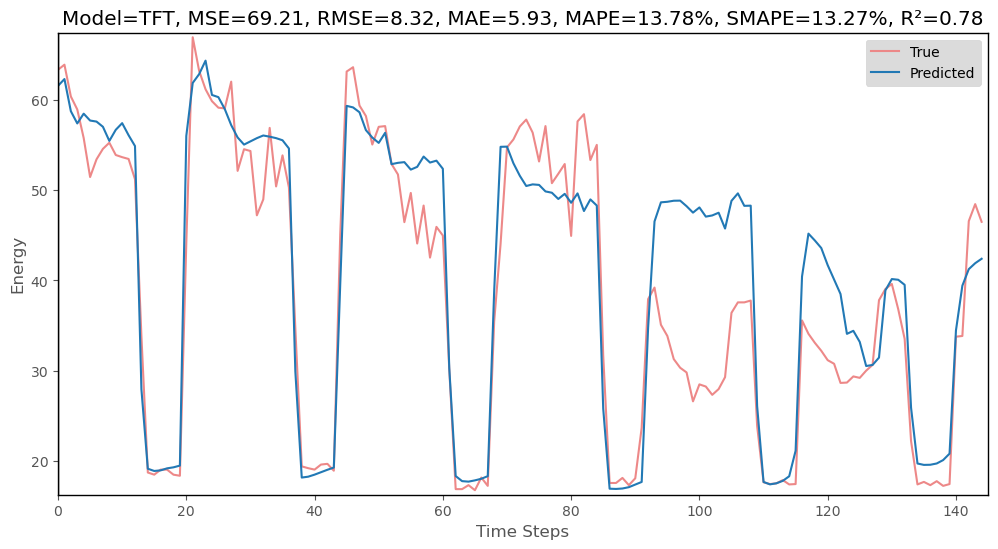

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


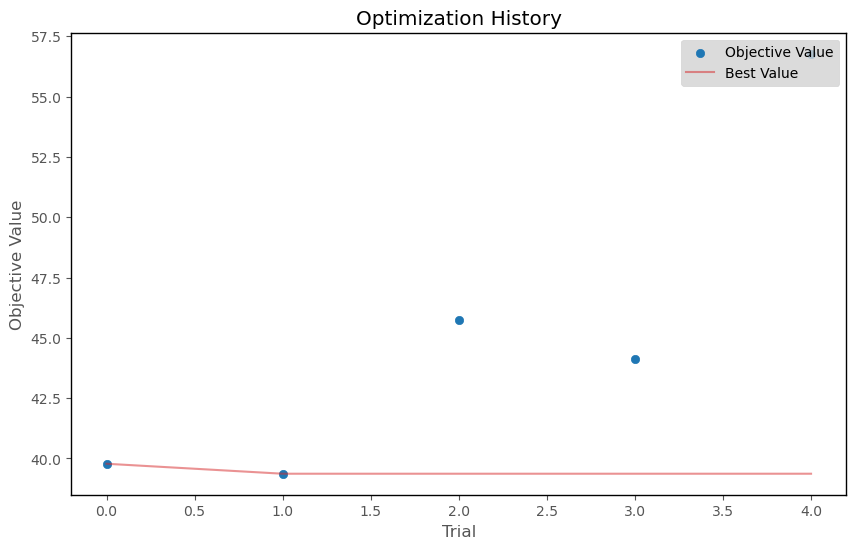

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step


[I 2025-01-05 23:18:07,667] A new study created in memory with name: no-name-a7889502-df44-4cff-a0dc-88b7eec29ac2
[I 2025-01-05 23:19:41,856] Trial 4 finished with value: 39.60242698649095 and parameters: {'n_estimators': 34, 'max_depth': 4, 'min_samples_split': 9, 'min_samples_leaf': 9}. Best is trial 4 with value: 39.60242698649095.
[I 2025-01-05 23:20:39,990] Trial 3 finished with value: 27.66611659829448 and parameters: {'n_estimators': 26, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 7}. Best is trial 3 with value: 27.66611659829448.
[I 2025-01-05 23:22:22,440] Trial 0 finished with value: 31.253744756193832 and parameters: {'n_estimators': 87, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 9}. Best is trial 3 with value: 27.66611659829448.
[I 2025-01-05 23:22:33,384] Trial 2 finished with value: 26.87769294898621 and parameters: {'n_estimators': 55, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 2 with value: 26.877692

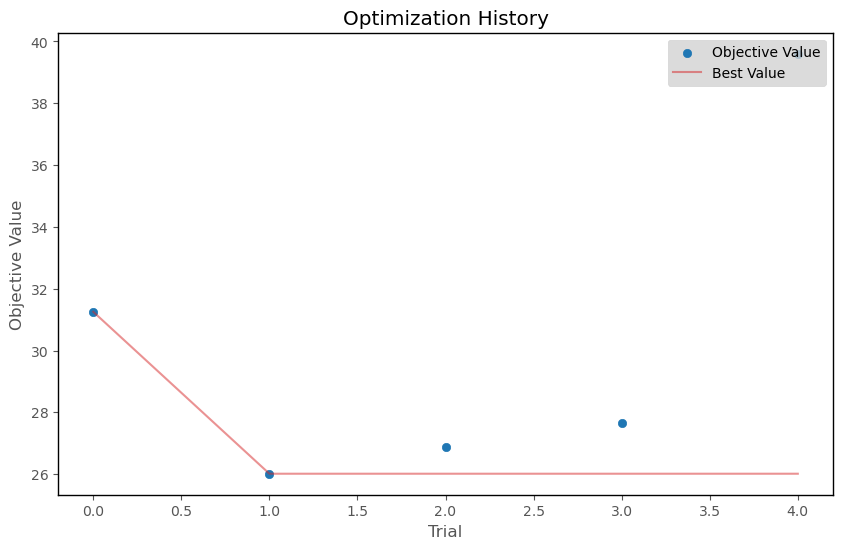

[I 2025-01-05 23:28:52,421] A new study created in memory with name: no-name-5f571a56-7183-4850-a4bb-4c6b83d542eb
[I 2025-01-05 23:30:08,032] Trial 0 finished with value: 45.66543197631836 and parameters: {'d_model': 71, 'num_heads': 2, 'num_transformer_layers': 2, 'ff_dim': 122, 'dropout_rate': 0.11221381309140482, 'learning_rate': 0.0008354484007867537, 'optimizer': 'adam'}. Best is trial 0 with value: 45.66543197631836.
[I 2025-01-05 23:33:08,098] Trial 1 finished with value: 49.69721221923828 and parameters: {'d_model': 122, 'num_heads': 4, 'num_transformer_layers': 6, 'ff_dim': 62, 'dropout_rate': 0.49760394633224914, 'learning_rate': 0.00043074170719934433, 'optimizer': 'adam'}. Best is trial 0 with value: 45.66543197631836.
[I 2025-01-05 23:34:48,911] Trial 2 finished with value: 45.55998611450195 and parameters: {'d_model': 83, 'num_heads': 7, 'num_transformer_layers': 2, 'ff_dim': 174, 'dropout_rate': 0.17920902407020975, 'learning_rate': 0.0006421585730941279, 'optimizer': 'a

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


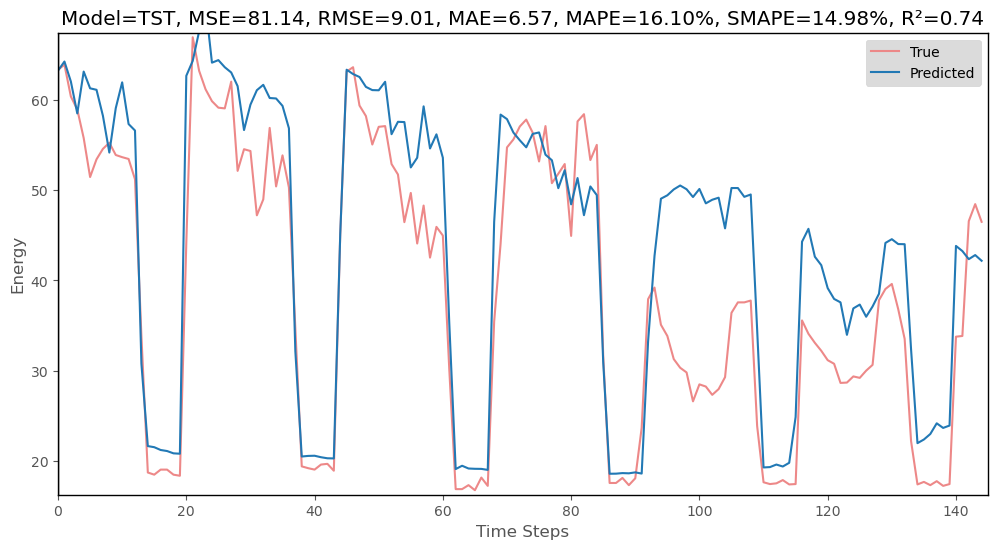

D:\GoogleDrive\phd\Paper 2\Functions\main.py:638: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study).figure


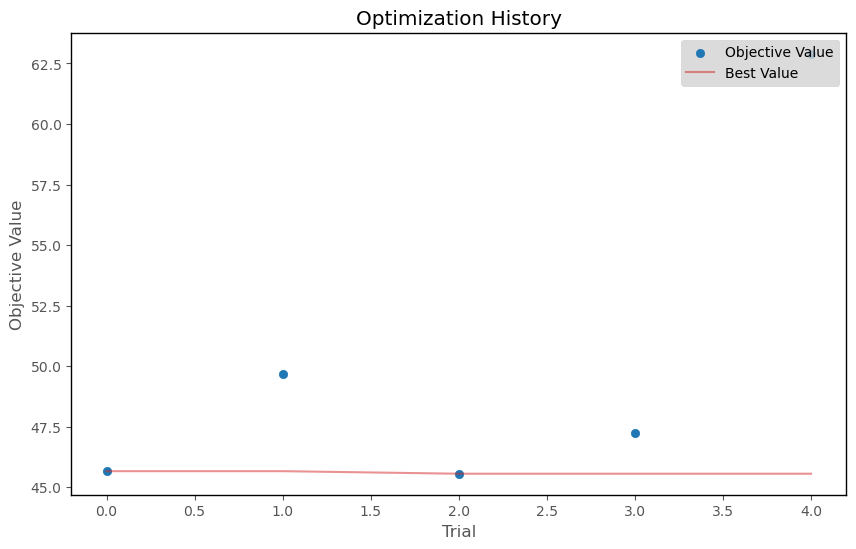

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step


[I 2025-01-05 23:42:48,610] A new study created in memory with name: no-name-c7119885-f79f-435d-8ddc-cc57eb010b47
[I 2025-01-05 23:43:41,279] Trial 1 finished with value: 12.510700083564652 and parameters: {'n_estimators': 24, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 1 with value: 12.510700083564652.
[I 2025-01-05 23:43:53,280] Trial 2 finished with value: 6.504030951509686 and parameters: {'n_estimators': 13, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 2 with value: 6.504030951509686.
[I 2025-01-05 23:46:01,431] Trial 3 finished with value: 7.130136858413243 and parameters: {'n_estimators': 51, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 2 with value: 6.504030951509686.
[I 2025-01-05 23:48:52,037] Trial 4 finished with value: 5.9456801360128635 and parameters: {'n_estimators': 58, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 6}. Best is trial 4 with value: 5.9456801

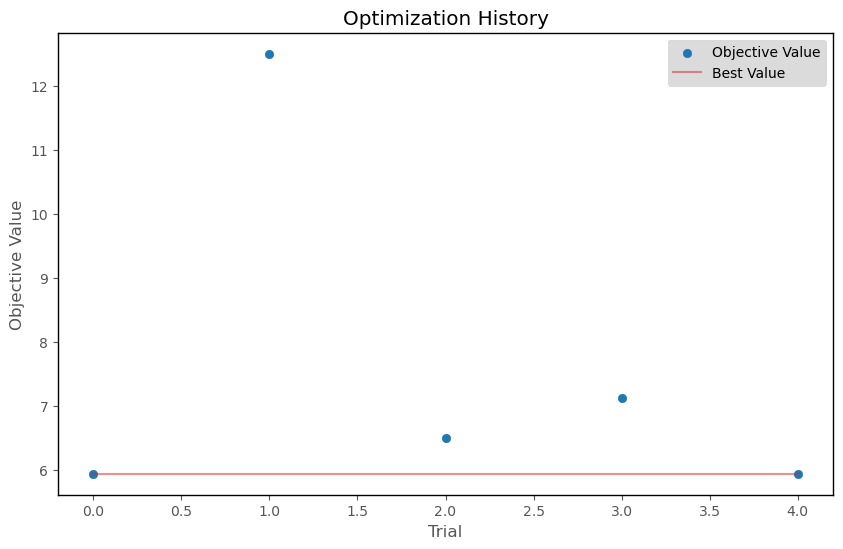

In [38]:
model_types = ['LSTM', 'GRU', 'BLSTM', 'BGRU', 'CNN', 'TCN', 'DCNN', 'WaveNet', 'TFT', 'TST']
# model_types = ['TCN']

data = (mydata.X_train, mydata.y_train, mydata.X_val, mydata.y_val, mydata.X_test, mydata.y_test)

for model_type in model_types:
    main.optimize_and_save_model(data=data, df_name=mydata.data_type, n_trials=5, epochs=100, verbosity=0, model_type=model_type, more_info=mydata.more_info)
    main.load_and_analyze_model(data=data, df_name=mydata.data_type, model_type=model_type, more_info=mydata.more_info)
    main.optimize_and_save_rf_model(data=data, df_name=mydata.data_type, n_trials=5, verbosity=0, model_type=model_type, more_info=mydata.more_info)

In [10]:
from sklearn.cluster import KMeans
import numpy as np

# Reshape X_train from (1000, 48, 10) to (1000, 480)
X_train_reshaped = mydata.X_train.reshape(mydata.X_train.shape[0], -1)  # Flatten (48, 10) into 480

# Apply KMeans clustering
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X_train_reshaped)

# Extract cluster centers
background = kmeans.cluster_centers_

# Print the shape of the background for verification
print("Shape of background (cluster centers):", background.shape)


Shape of background (cluster centers): (10, 480)


In [67]:
xai_methods = ['Kernel', 'Tree', 'Permutation', 'Sampling', 'Partition', 'Lime', 'Custom']
for xai_method in xai_methods:
    main.myshap(data=data, df_name=mydata.data_type, features_name=mydata.feature_names, background_training= background, target_column='energy_consumption', anomaly_id=1, model_type=model_types[0], horizon=0, 
            xai_method=xai_method, more_info=mydata.more_info)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
940/940 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Data saved to SQLite database successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Data saved to SQLite database successfully.
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Data saved to SQLite database successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
7/7 ━━━━━━━━

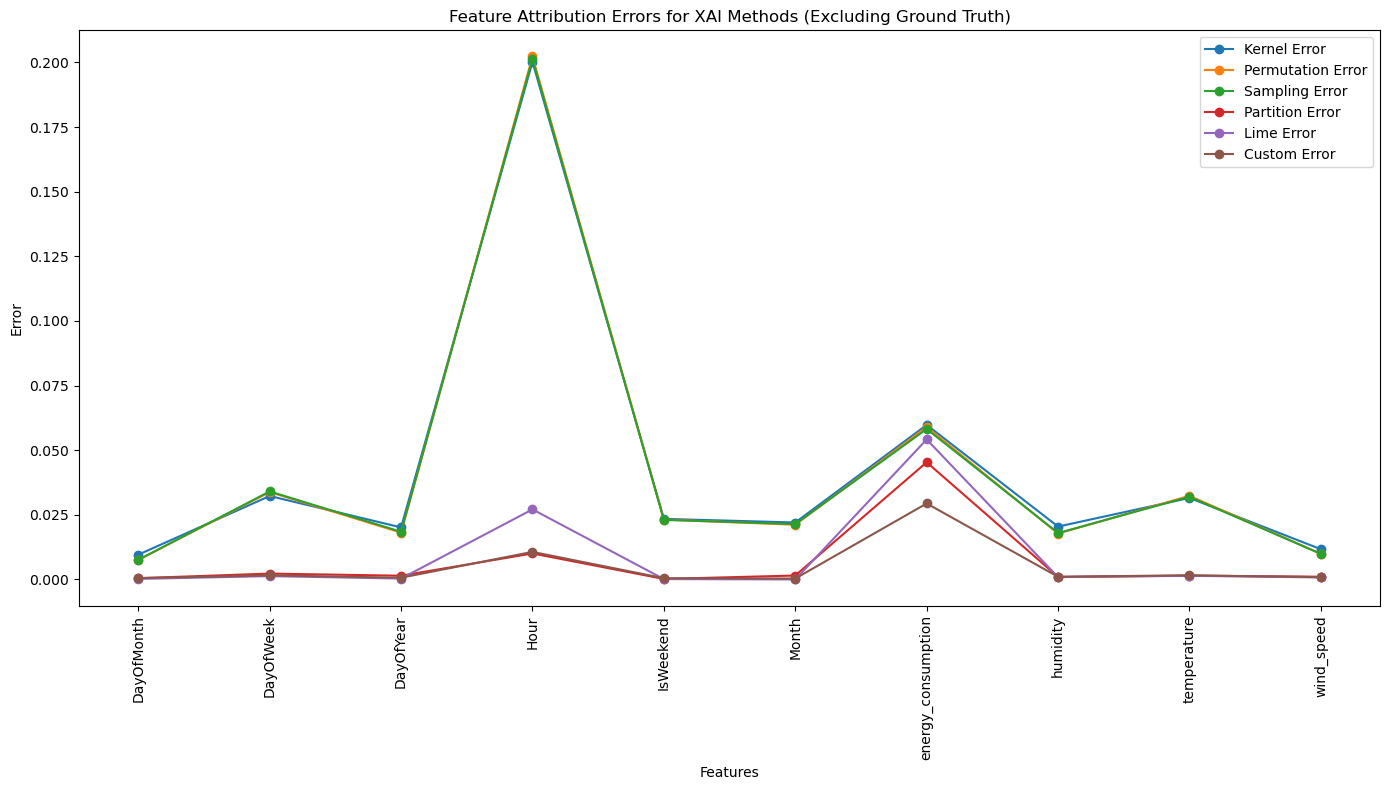

In [69]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.spatial.distance import cosine
from scipy.stats import kendalltau, entropy
import matplotlib.pyplot as plt
import io

# Function to fetch shap_df with specified conditions
def fetch_shap_df(database_path, df_name, anomaly_id, model_type, xai_method):
    """
    Fetch data from the 'shap_df' column in the 'XAI' table with specified conditions.

    Args:
        database_path (str): Path to the SQLite database file.
        df_name (str): The value of the dataset_name column to filter by.
        anomaly_id (int): The value of the anomaly_id column to filter by.
        model_type (str): The value of the model_type column to filter by.
        xai_method (str): The value of the xai_method column to filter by.

    Returns:
        pd.DataFrame: A DataFrame parsed from the shap_df JSON data if found.
    """
    conn = sqlite3.connect(database_path)
    cursor = conn.cursor()

    query = """
    SELECT shap_df
    FROM XAI
    WHERE dataset_name = ? AND anomaly_id = ? AND model_type = ? AND xai_method = ?
    """
    cursor.execute(query, (df_name, anomaly_id, model_type, xai_method))
    result = cursor.fetchone()
    conn.close()

    if result:
        shap_df = pd.read_json(io.StringIO(result[0]))  # Fixed to avoid the warning
        return shap_df
    else:
        print(f"No data found for the conditions: {df_name}, {anomaly_id}, {model_type}, {xai_method}")
        return None

# Function to compare SHAP values between methods
def compare_xai_methods(database_path, methods_to_compare, df_name, anomaly_id, model_type, ground_truth_method="Tree"):
    """
    Compare SHAP values for XAI methods using a ground truth method.

    Args:
        database_path (str): Path to the SQLite database.
        methods_to_compare (list): List of XAI methods to compare.
        df_name (str): Dataset name to filter by.
        anomaly_id (int): Anomaly ID to filter by.
        model_type (str): Model type to filter by.
        ground_truth_method (str): The ground truth method (default is "Tree").
    """
    ground_truth_shap_df = fetch_shap_df(database_path, df_name, anomaly_id, model_type, ground_truth_method)
    if ground_truth_shap_df is None:
        print(f"No data found for the ground truth method: {ground_truth_method}")
        return None, None

    ground_truth_shap = ground_truth_shap_df.to_numpy()

    metrics = []
    all_feature_errors = []

    for method in methods_to_compare:
        if method == ground_truth_method:
            continue

        shap_df = fetch_shap_df(database_path, df_name, anomaly_id, model_type, method)
        if shap_df is None:
            print(f"No data found for method: {method}")
            continue

        shap_values = shap_df.to_numpy()

        # Calculate metrics
        mae = mean_absolute_error(ground_truth_shap, shap_values)
        mse = mean_squared_error(ground_truth_shap, shap_values)

        # Cosine Similarity
        cosine_similarity = 1 - cosine(ground_truth_shap.flatten(), shap_values.flatten())

        # Kendall Tau Rank Correlation
        kendall_tau, _ = kendalltau(ground_truth_shap.flatten(), shap_values.flatten())

        # KL Divergence
        kl_divergence = entropy(ground_truth_shap.flatten(), shap_values.flatten())

        metrics.append(
            {
                "Method": method,
                "MAE": mae,
                "MSE": mse,
                "Cosine Similarity": cosine_similarity,
                "Kendall Tau": kendall_tau,
                "KL Divergence": kl_divergence,
            }
        )

        # Collect feature-wise errors
        feature_errors = np.abs(ground_truth_shap - shap_values).mean(axis=0)
        all_feature_errors.append(
            pd.DataFrame({
                "Feature": shap_df.columns,  # Use column names from shap_df
                f"{method} Error": feature_errors
            })
        )

    # Create DataFrame for metrics
    metrics_df = pd.DataFrame(metrics)

    # Merge all feature errors into a single DataFrame
    if all_feature_errors:
        feature_error_df = all_feature_errors[0]
        for i in range(1, len(all_feature_errors)):
            feature_error_df = feature_error_df.merge(all_feature_errors[i], on="Feature", how="outer")

        # Plot feature attribution errors for all methods except ground_truth_method
        plt.figure(figsize=(14, 8))
        for method in methods_to_compare:
            if method == ground_truth_method:
                continue
            plt.plot(
                feature_error_df["Feature"], feature_error_df[f"{method} Error"], label=f"{method} Error", marker="o"
            )
        plt.xticks(rotation=90)
        plt.xlabel("Features")
        plt.ylabel("Error")
        plt.title("Feature Attribution Errors for XAI Methods (Excluding Ground Truth)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return metrics_df, feature_error_df


# Example usage
database_path = "./Results/result.db"
df_name = mydata.data_type
anomaly_id = 1
model_type = model_types[0]
xai_methods = ['Kernel', 'Tree', 'Permutation', 'Sampling', 'Partition', 'Lime', 'Custom']

# Compare methods and display results
metrics_df, feature_error_df = compare_xai_methods(database_path, xai_methods, df_name, anomaly_id, model_type, ground_truth_method="Tree")
show_df(metrics_df)
show_df(feature_error_df)


In [13]:
# def generate_sequential_feature_names(mydata):
#     feature_names = []
#     for i in range(1, mydata.X_train.shape[1] + 1):
#         for feature in mydata.feature_names:
#             feature_names.append(f"{feature}_{i}")
#     return feature_names

# feature_names = generate_sequential_feature_names(mydata)
mydata.feature_names

['Hour',
 'DayOfWeek',
 'DayOfMonth',
 'Month',
 'DayOfYear',
 'IsWeekend',
 'temperature',
 'humidity',
 'wind_speed',
 'energy_consumption']

# Incremental Clustering and SHAP (Simple Neural Network)

In [15]:
# import numpy as np
# import pandas as pd
# import shap
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from sklearn.cluster import MiniBatchKMeans
# from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error, r2_score
# import matplotlib.pyplot as plt
# import os
# import sqlite3
# from tensorflow.keras.models import load_model
# import warnings

# # Suppress specific FutureWarnings from torch.load related to 'weights_only'
# warnings.filterwarnings(
#     "ignore",
#     category=FutureWarning,
#     message=".*weights_only.*"
# )

# # Flatten data utility
# def flatten_data(X):
#     """Flatten 3D data (n_samples, seq_length, n_features) into 2D data (n_samples, seq_length * n_features)."""
#     return X.reshape(X.shape[0], -1)

# # Incremental clustering class
# class IncrementalKMeans:
#     def __init__(self, n_clusters, n_features):
#         self.kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
#         self.n_features = n_features

#     def update(self, X):
#         """Incrementally update the cluster centroids with new data."""
#         self.kmeans.partial_fit(X)

#     def get_centroids(self):
#         """Retrieve the current cluster centroids."""
#         return self.kmeans.cluster_centers_

#     def get_distances_to_centroids(self, X):
#         """Compute distances from data points to the current centroids."""
#         return pairwise_distances(X, self.kmeans.cluster_centers_)

# # Define a neural network with dropout and batch normalization for SHAP prediction
# class SHAPSurrogateNN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(SHAPSurrogateNN, self).__init__()
#         self.network = nn.Sequential(
#             nn.Linear(input_dim, 256),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.Dropout(0.4),
#             nn.Linear(256, 128),
#             nn.BatchNorm1d(128),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Linear(64, output_dim)
#         )
    
#     def forward(self, x):
#         return self.network(x)

# # Select the most different points
# def select_most_different_points(X, centroids, top_percent=5):
#     """Select the most different points inside a batch and relative to centroids."""
#     # Compute distances within the batch
#     distances_within = pairwise_distances(X, X)

#     # Compute distances to centroids
#     distances_to_centroids = pairwise_distances(X, centroids)

#     # Select top percent most different points inside the batch
#     avg_distances_within = distances_within.mean(axis=1)
#     n_select_within = max(1, int(len(X) * top_percent / 100))
#     selected_within_idx = np.argsort(-avg_distances_within)[:n_select_within]

#     # Select top percent most different points relative to centroids
#     avg_distances_to_centroids = distances_to_centroids.mean(axis=1)
#     n_select_centroids = max(1, int(len(X) * top_percent / 100))
#     selected_centroids_idx = np.argsort(-avg_distances_to_centroids)[:n_select_centroids]

#     # Combine selected indices
#     selected_indices = np.unique(np.concatenate((selected_within_idx, selected_centroids_idx)))

#     return X[selected_indices], selected_indices

# # Calculate SMAPE
# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_pred - y_true) / denominator
#     diff[denominator == 0] = 0.0
#     return np.mean(diff) * 100

# # Process batches with incremental validation
# def process_batches_with_dynamic_validation(
#     mydata,
#     model_type,
#     horizon=0,
#     n_clusters=5,
#     batch_size=50,
#     validation_split=0.2,
#     top_percent=5,
#     n_epochs=5,
#     learning_rate=0.001,
#     shap_method="Kernel",
#     nsamples=None,  # User-defined SHAP samples
#     random_state=42,
#     patience=3
# ):
#     """
#     Incremental clustering, SHAP explainability, and neural network training with configurable options.

#     Parameters:
#     - data: tuple, containing (X_train, y_train, X_val, y_val, X_test, y_test).
#     - df_name: str, name of the dataset.
#     - model_type: str, type of the model being used.
#     - more_info: str, additional information about the experiment.
#     - horizon: int, specifies the output horizon for predictions.
#     - n_clusters: int, number of clusters for Incremental K-Means.
#     - batch_size: int, size of each batch.
#     - validation_split: float, proportion of each batch to use as validation data.
#     - top_percent: float, percentage of most different data points to select.
#     - n_epochs: int, number of epochs to train the neural network for each batch.
#     - learning_rate: float, learning rate for the neural network optimizer.
#     - shap_method: str, SHAP explainability method (e.g., "Kernel").
#     - nsamples: int or None, number of samples for SHAP computation. Default is 2 * n_features + 2048.
#     - random_state: int, random state for reproducibility.
#     - patience: int, early stopping patience.

#     Returns:
#     - results_df: DataFrame containing evaluation metrics.
#     """
#     data = (mydata.X_train, mydata.y_train, mydata.X_val, mydata.y_val, mydata.X_test, mydata.y_test)
#     df_name=mydata.data_type
#     more_info=mydata.more_info
#     features_name=mydata.feature_names
    
#     # Set default nsamples if not provided
#     if nsamples is None:
#         # Assuming input_dim is number of features after flattening
#         input_dim = flatten_data(data[0]).shape[1]
#         nsamples = 2 * input_dim + 2048
#     print(f"SHAP computation will use nsamples={nsamples}")
    
#     # Set random seeds for reproducibility
#     torch.manual_seed(random_state)
#     np.random.seed(random_state)

#     # Unpack data
#     X_train, y_train, X_val, y_val, X_test, y_test = data

#     # Initialize clustering
#     kmeans = IncrementalKMeans(n_clusters=n_clusters, n_features=flatten_data(X_train).shape[1])

#     # Load the best base model dynamically (assumed to be a Keras model)
#     def load_best_model(df_name, model_type):
#         model_dir = f"./Results/Models/{df_name}"
#         model_path = f"{model_dir}/{model_type}.keras"
#         if not os.path.exists(model_path):
#             raise FileNotFoundError(f"Model not found at {model_path}. Please check the path and ensure the model exists.")
#         return load_model(model_path), model_path

#     best_model, model_path = load_best_model(df_name, model_type)
#     # Removed the unwanted print statement

#     # Define model prediction function for SHAP
#     def model_predict(data):
#         predictions = best_model.predict(data.reshape((-1, X_train.shape[1], X_train.shape[2])))
#         return predictions[:, horizon] if len(predictions.shape) > 1 else predictions
        
#     # Initialize surrogate neural network
#     input_dim = flatten_data(X_train).shape[1]
#     # Determine output_dim based on SHAP values (one per feature)
#     output_dim = input_dim  # One SHAP value per feature
#     nn_model = SHAPSurrogateNN(input_dim=input_dim, output_dim=output_dim)
#     optimizer = optim.Adam(nn_model.parameters(), lr=learning_rate, weight_decay=1e-4)
#     criterion = nn.MSELoss()

#     # Move model to device
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     nn_model.to(device)
#     print(f"Using device: {device}")

#     # DataFrame to store results
#     results = []

#     # Define the directory to save results and models
#     result_dir = f"./Results/SHAP/{df_name}/"
#     os.makedirs(result_dir, exist_ok=True)

#     # Initialize SQLite connection outside the loop for efficiency
#     conn = sqlite3.connect("Results/result.db")

#     # Drop the existing SHAP_Incremental table if it exists to prevent schema mismatch
#     cursor = conn.cursor()
#     cursor.execute("DROP TABLE IF EXISTS SHAP_Incremental;")
#     conn.commit()
#     print("Dropped existing SHAP_Incremental table if it existed.")

#     # Process data in batches
#     for batch_index, batch_start in enumerate(range(0, X_train.shape[0], batch_size)):
#         batch_end = min(batch_start + batch_size, X_train.shape[0])
#         X_batch = X_train[batch_start:batch_end]
#         y_batch = y_train[batch_start:batch_end]

#         print(f"Processing Batch {batch_index}: Samples {batch_start} to {batch_end}")

#         # Flatten the batch for clustering
#         X_batch_flattened = flatten_data(X_batch)

#         # Update clustering with the batch data
#         kmeans.update(X_batch_flattened)
#         centroids = kmeans.get_centroids()

#         # Select the most different points
#         selected_data, selected_indices = select_most_different_points(X_batch_flattened, centroids, top_percent)
#         print(f"Selected {selected_data.shape[0]} diverse points for SHAP computation.")

#         # Explainability with KernelExplainer
#         if shap_method == "Kernel":
#             # Initialize KernelExplainer with a subset of centroids as background
#             background_size = min(nsamples, centroids.shape[0])
#             background = centroids[np.random.choice(centroids.shape[0], background_size, replace=False)]
#             explainer = shap.KernelExplainer(model_predict, background)
#         else:
#             raise ValueError(f"Unsupported SHAP method: {shap_method}")

#         print("Computing SHAP values...")
#         shap_values = explainer.shap_values(selected_data, nsamples=nsamples)
#         print('shap_values:', shap_values.shape)
        
#         # Convert data to tensors
#         X_selected_tensor = torch.tensor(selected_data, dtype=torch.float32).to(device)
#         shap_values_tensor = torch.tensor(shap_values, dtype=torch.float32).to(device)

#         # Initialize batch-specific early stopping parameters
#         best_val_loss = float('inf')
#         no_improvement = 0

#         # Optionally, create a validation split from the selected data
#         if validation_split > 0 and X_selected_tensor.shape[0] >= 2:
#             val_size = int(len(X_selected_tensor) * validation_split)
#             train_size = len(X_selected_tensor) - val_size
#             train_dataset, val_dataset = torch.utils.data.random_split(
#                 torch.utils.data.TensorDataset(X_selected_tensor, shap_values_tensor),
#                 [train_size, val_size]
#             )
#         else:
#             train_dataset = torch.utils.data.TensorDataset(X_selected_tensor, shap_values_tensor)
#             val_dataset = None

#         train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#         val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False) if val_dataset else None

#         # Training loop for the surrogate neural network on the selected data
#         for epoch in range(n_epochs):
#             nn_model.train()
#             epoch_losses = []
#             for X_batch_train, shap_batch_train in train_loader:
#                 optimizer.zero_grad()
#                 outputs = nn_model(X_batch_train)
#                 loss = criterion(outputs, shap_batch_train)
#                 loss.backward()
#                 optimizer.step()
#                 epoch_losses.append(loss.item())
#             avg_train_loss = np.mean(epoch_losses)

#             # Validation phase
#             if val_loader:
#                 nn_model.eval()
#                 val_losses = []
#                 with torch.no_grad():
#                     for X_batch_val, shap_batch_val in val_loader:
#                         outputs = nn_model(X_batch_val)
#                         loss = criterion(outputs, shap_batch_val)
#                         val_losses.append(loss.item())
#                 avg_val_loss = np.mean(val_losses)
#                 print(f"Batch {batch_index}, Epoch {epoch + 1}/{n_epochs}, Training Loss: {avg_train_loss:.6f}, Validation Loss: {avg_val_loss:.6f}")

#                 # Early stopping logic
#                 if avg_val_loss < best_val_loss:
#                     best_val_loss = avg_val_loss
#                     no_improvement = 0
#                     # Save the best model for this batch
#                     torch.save(nn_model.state_dict(), f"{result_dir}/{model_type}_batch_{batch_index}_best_ANN.pth")
#                 else:
#                     no_improvement += 1

#                 if no_improvement >= patience:
#                     print(f"Early stopping for Batch {batch_index} at Epoch {epoch + 1}")
#                     break
#             else:
#                 print(f"Batch {batch_index}, Epoch {epoch + 1}/{n_epochs}, Training Loss: {avg_train_loss:.6f}")

#         # Load the best model for predictions
#         best_model_path = f"{result_dir}/{model_type}_batch_{batch_index}_best_ANN.pth"
#         if os.path.exists(best_model_path):
#             nn_model.load_state_dict(torch.load(best_model_path, map_location=device))
#             print(f"Loaded best model for Batch {batch_index} from {best_model_path}")
#         else:
#             print(f"Best model for Batch {batch_index} not found. Using current model state.")

#         nn_model.eval()

#         # Predict SHAP values using the surrogate model
#         with torch.no_grad():
#             shap_pred = nn_model(X_selected_tensor).cpu().numpy()
        
#         print('shap_pred:', shap_pred.shape)
        
#         # Calculate evaluation metrics
#         mse = mean_squared_error(shap_values, shap_pred)
#         mae = mean_absolute_error(shap_values, shap_pred)
#         smape_val = smape(shap_values, shap_pred)
#         r2 = r2_score(shap_values, shap_pred)

#         # Save all data for the batch in a DataFrame string format
#         batch_df = pd.DataFrame(selected_data)
#         batch_df_str = batch_df.to_json()

#         # Save SHAP values in a DataFrame string format
#         shap_df = pd.DataFrame(shap_values, columns=[f"SHAP_{i+1}" for i in range(shap_values.shape[1])])
#         shap_df_str = shap_df.to_json()

#         # Save predicted SHAP values in a DataFrame string format
#         shap_pred_df = pd.DataFrame(shap_pred, columns=[f"SHAP_Pred_{i+1}" for i in range(shap_pred.shape[1])])
#         shap_pred_df_str = shap_pred_df.to_json()

#         # Append results for the current batch
#         results.append({
#             "Dataset": df_name,
#             "Model": model_type,
#             "MoreInfo": more_info,
#             "BatchIndex": batch_index,
#             "BatchData": batch_df_str,
#             "Centroids": pd.DataFrame(centroids).to_json(),
#             "SelectedData": pd.DataFrame(selected_data).to_json(),
#             "SHAPValues": shap_df_str,
#             "SHAPPredictions": shap_pred_df_str,
#             "MSE": mse,
#             "MAE": mae,
#             "SMAPE": smape_val,
#             "R2": r2
#         })

#         # Save results to SQLite database
#         results_df = pd.DataFrame(results)
#         results_df.to_sql("SHAP_Incremental", conn, if_exists="append", index=False)

#         # Plotting
#         from matplotlib.backends.backend_pdf import PdfPages
#         import matplotlib.pyplot as plt
                
#         # Number of samples, sequences, and features
#         num_samples = shap_values.shape[0]  # Dynamically get the number of samples
#         num_sequences = X_train.shape[1]  # Number of sequences from X_train
#         num_features = X_train.shape[2]  # Number of features from X_train
        
#         reshaped_shap_values = shap_values.reshape(num_samples, num_sequences, num_features)
#         reshaped_shap_pred = shap_pred.reshape(num_samples, num_sequences, num_features)
        
#         # Open a PDF to save all plots
#         with PdfPages(f"{result_dir}/shap_values_per_feature_batch_{batch_index}.pdf") as pdf:
#             # Iterate through each feature
#             for feature_idx, feature_name in enumerate(features_name):
#                 # Extract SHAP values and predicted values for the current feature
#                 shap_values_feature = reshaped_shap_values[:, :, feature_idx]  # Shape: (num_samples, num_sequences)
#                 pred_values_feature = reshaped_shap_pred[:, :, feature_idx]  # Shape: (num_samples, num_sequences)
        
#                 # Calculate mean and standard deviation across samples for each sequence
#                 mean_shap_values = shap_values_feature.mean(axis=0)
#                 std_shap_values = shap_values_feature.std(axis=0)
#                 mean_pred_values = pred_values_feature.mean(axis=0)
#                 std_pred_values = pred_values_feature.std(axis=0)
        
#                 # Plot for the current feature
#                 plt.figure(figsize=(10, 6))
        
#                 # Plot SHAP values (kernel) with error bars
#                 plt.errorbar(
#                     range(num_sequences),  # x-axis: sequence index
#                     mean_shap_values,
#                     yerr=std_shap_values,
#                     fmt='o-',
#                     capsize=5,
#                     label='Kernel SHAP Values',
#                     color='blue'
#                 )
        
#                 # Plot predicted SHAP values with error bars
#                 plt.errorbar(
#                     range(num_sequences),  # x-axis: sequence index
#                     mean_pred_values,
#                     yerr=std_pred_values,
#                     fmt='o-',
#                     capsize=5,
#                     label='Predicted SHAP Values',
#                     color='orange'
#                 )
        
#                 # Customize the plot
#                 plt.title(f"Feature: {feature_name}")
#                 plt.xlabel('Sequence Index')
#                 plt.ylabel('SHAP Values')
#                 plt.legend()
#                 plt.grid(True, linestyle='--', alpha=0.7)
#                 plt.tight_layout()
        
#                 # Save the current figure to the PDF
#                 pdf.savefig()
#                 plt.close()
               
#         print(f"Batch {batch_index} processed. Metrics: MSE={mse:.6f}, MAE={mae:.6f}, SMAPE={smape_val:.2f}%, R2={r2:.6f}")

#     # Close the SQLite connection after all batches are processed
#     conn.close()

#     # Save the trained surrogate neural network
#     final_model_path = f"./Results/Models/{df_name}/"
#     os.makedirs(final_model_path, exist_ok=True)
#     torch.save(nn_model.state_dict(), f"{final_model_path}/{model_type}_SHAP_Surrogate.pth")

#     print("Processing complete. Results and plots have been saved.")

#     return results_df


# # Example base model loading (Ensure your base model is saved at the specified path)
# model_type = model_types[0]
# data = (mydata.X_train, mydata.y_train, mydata.X_val, mydata.y_val, mydata.X_test, mydata.y_test)

# results_df = process_batches_with_dynamic_validation(
#     mydata=mydata,
#     model_type=model_type,
#     horizon=0,
#     n_clusters=5,
#     batch_size=100,
#     validation_split=0.2,
#     top_percent=5,
#     n_epochs=100,
#     learning_rate=0.0001,
#     shap_method="Kernel",
#     # nsamples=100,  # Optional: Specify the number of samples for SHAP
#     random_state=42,
#     patience=10
# )

# # print(results_df)

# Incremental Clustering and SHAP (CNN)

In [17]:
# import numpy as np
# import pandas as pd
# import shap
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from sklearn.cluster import MiniBatchKMeans
# from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error, r2_score
# import matplotlib.pyplot as plt
# import os
# import sqlite3
# from tensorflow.keras.models import load_model
# import warnings

# # Suppress specific FutureWarnings from torch.load related to 'weights_only'
# warnings.filterwarnings(
#     "ignore",
#     category=FutureWarning,
#     message=".*weights_only.*"
# )

# # Flatten data utility
# def flatten_data(X):
#     """
#     Flatten 3D data (n_samples, seq_length, n_features) into 2D data 
#     (n_samples, seq_length * n_features).
#     """
#     return X.reshape(X.shape[0], -1)

# # Incremental clustering class
# class IncrementalKMeans:
#     def __init__(self, n_clusters, n_features):
#         self.kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
#         self.n_features = n_features

#     def update(self, X):
#         """Incrementally update the cluster centroids with new data."""
#         self.kmeans.partial_fit(X)

#     def get_centroids(self):
#         """Retrieve the current cluster centroids."""
#         return self.kmeans.cluster_centers_

#     def get_distances_to_centroids(self, X):
#         """Compute distances from data points to the current centroids."""
#         return pairwise_distances(X, self.kmeans.cluster_centers_)

# # Define a Convolutional Neural Network with dropout and batch normalization for SHAP prediction
# class SHAPSurrogateCNN(nn.Module):
#     def __init__(self, input_length, n_features, output_dim):
#         super(SHAPSurrogateCNN, self).__init__()
#         self.conv1 = nn.Conv1d(in_channels=n_features, out_channels=64, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm1d(64)
#         self.relu = nn.ReLU()
#         self.dropout = nn.Dropout(0.4)
        
#         self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm1d(128)
#         self.relu2 = nn.ReLU()
        
#         self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
#         self.bn3 = nn.BatchNorm1d(256)
#         self.relu3 = nn.ReLU()
        
#         self.flatten = nn.Flatten()
#         self.fc1 = nn.Linear(256 * input_length, 256)
#         self.bn4 = nn.BatchNorm1d(256)
#         self.dropout2 = nn.Dropout(0.3)
#         self.fc2 = nn.Linear(256, 128)
#         self.bn5 = nn.BatchNorm1d(128)
#         self.relu4 = nn.ReLU()
#         self.fc3 = nn.Linear(128, output_dim)  # Ensure this matches the target size
        
#     def forward(self, x):
#         x = self.conv1(x)
#         x = self.bn1(x)
#         x = self.relu(x)
#         x = self.dropout(x)
        
#         x = self.conv2(x)
#         x = self.bn2(x)
#         x = self.relu2(x)
        
#         x = self.conv3(x)
#         x = self.bn3(x)
#         x = self.relu3(x)
        
#         x = self.flatten(x)
#         x = self.fc1(x)
#         x = self.bn4(x)
#         x = self.relu4(x)
#         x = self.dropout2(x)
        
#         x = self.fc2(x)
#         x = self.bn5(x)
#         x = self.relu4(x)
        
#         x = self.fc3(x)  # Final output
#         return x

# # Select the most different points
# def select_most_different_points(X, centroids, top_percent=5):
#     """
#     Select the most different points inside a batch and relative to centroids.
#     """
#     # Compute distances within the batch
#     distances_within = pairwise_distances(X, X)

#     # Compute distances to centroids
#     distances_to_centroids = pairwise_distances(X, centroids)

#     # Select top percent most different points inside the batch
#     avg_distances_within = distances_within.mean(axis=1)
#     n_select_within = max(1, int(len(X) * top_percent / 100))
#     selected_within_idx = np.argsort(-avg_distances_within)[:n_select_within]

#     # Select top percent most different points relative to centroids
#     avg_distances_to_centroids = distances_to_centroids.mean(axis=1)
#     n_select_centroids = max(1, int(len(X) * top_percent / 100))
#     selected_centroids_idx = np.argsort(-avg_distances_to_centroids)[:n_select_centroids]

#     # Combine selected indices
#     selected_indices = np.unique(np.concatenate((selected_within_idx, selected_centroids_idx)))

#     return X[selected_indices], selected_indices

# # Calculate SMAPE
# def smape(y_true, y_pred):
#     """
#     Calculate Symmetric Mean Absolute Percentage Error.
#     """
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_pred - y_true) / denominator
#     diff[denominator == 0] = 0.0
#     return np.mean(diff) * 100

# # Process batches with incremental validation
# def process_batches_with_dynamic_validation(
#     mydata,
#     model_type,
#     horizon=0,
#     n_clusters=5,
#     batch_size=50,
#     validation_split=0.2,
#     top_percent=5,
#     n_epochs=5,
#     learning_rate=0.001,
#     shap_method="Kernel",
#     nsamples=None,  # User-defined SHAP samples
#     random_state=42,
#     patience=3
# ):
#     """
#     Incremental clustering, SHAP explainability, and neural network training with configurable options.

#     Parameters:
#     - mydata: object containing datasets and metadata.
#     - model_type: str, type of the model being used.
#     - horizon: int, specifies the output horizon for predictions.
#     - n_clusters: int, number of clusters for Incremental K-Means.
#     - batch_size: int, size of each batch.
#     - validation_split: float, proportion of each batch to use as validation data.
#     - top_percent: float, percentage of most different data points to select.
#     - n_epochs: int, number of epochs to train the neural network for each batch.
#     - learning_rate: float, learning rate for the neural network optimizer.
#     - shap_method: str, SHAP explainability method (e.g., "Kernel").
#     - nsamples: int or None, number of samples for SHAP computation. Default is 2 * n_features + 2048.
#     - random_state: int, random state for reproducibility.
#     - patience: int, early stopping patience.

#     Returns:
#     - results_df: DataFrame containing evaluation metrics.
#     """
#     # Unpack data and metadata from mydata
#     data = (mydata.X_train, mydata.y_train, mydata.X_val, mydata.y_val, mydata.X_test, mydata.y_test)
#     df_name = mydata.data_type
#     more_info = mydata.more_info
#     features_name = mydata.feature_names

#     # Set default nsamples if not provided
#     if nsamples is None:
#         # Assuming input_dim is number of features after flattening
#         input_dim = flatten_data(data[0]).shape[1]
#         nsamples = 2 * input_dim + 2048
#     print(f"SHAP computation will use nsamples={nsamples}")

#     # Set random seeds for reproducibility
#     torch.manual_seed(random_state)
#     np.random.seed(random_state)

#     # Unpack data
#     X_train, y_train, X_val, y_val, X_test, y_test = data

#     # Initialize clustering
#     kmeans = IncrementalKMeans(n_clusters=n_clusters, n_features=flatten_data(X_train).shape[1])

#     # Load the best base model dynamically (assumed to be a Keras model)
#     def load_best_model(df_name, model_type):
#         model_dir = f"./Results/Models/{df_name}"
#         model_path = f"{model_dir}/{model_type}.keras"
#         if not os.path.exists(model_path):
#             raise FileNotFoundError(f"Model not found at {model_path}. Please check the path and ensure the model exists.")
#         return load_model(model_path), model_path

#     best_model, model_path = load_best_model(df_name, model_type)
#     # Removed the unwanted print statement

#     # Define model prediction function for SHAP
#     def model_predict(data):
#         predictions = best_model.predict(data.reshape((-1, X_train.shape[1], X_train.shape[2])))
#         return predictions[:, horizon] if len(predictions.shape) > 1 else predictions

#     # Initialize surrogate CNN model
#     seq_length = X_train.shape[1]       # e.g., 10
#     n_features = X_train.shape[2]       # e.g., 48
#     output_dim = seq_length * n_features # 10 * 48 = 480

#     nn_model = SHAPSurrogateCNN(input_length=seq_length, n_features=n_features, output_dim=output_dim)
#     optimizer = optim.Adam(nn_model.parameters(), lr=learning_rate, weight_decay=1e-4)
#     criterion = nn.MSELoss()

#     # Move model to device
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     nn_model.to(device)
#     print(f"Using device: {device}")

#     # DataFrame to store results
#     results = []

#     # Define the directory to save results and models
#     result_dir = f"./Results/SHAP/{df_name}/"
#     os.makedirs(result_dir, exist_ok=True)

#     # Initialize SQLite connection outside the loop for efficiency
#     conn = sqlite3.connect("Results/result.db")

#     # Drop the existing SHAP_Incremental table if it exists to prevent schema mismatch
#     cursor = conn.cursor()
#     cursor.execute("DROP TABLE IF EXISTS SHAP_Incremental;")
#     conn.commit()
#     print("Dropped existing SHAP_Incremental table if it existed.")

#     # Process data in batches
#     for batch_index, batch_start in enumerate(range(0, X_train.shape[0], batch_size)):
#         batch_end = min(batch_start + batch_size, X_train.shape[0])
#         X_batch = X_train[batch_start:batch_end]
#         y_batch = y_train[batch_start:batch_end]

#         print(f"\nProcessing Batch {batch_index}: Samples {batch_start} to {batch_end}")

#         # Flatten the batch for clustering
#         X_batch_flattened = flatten_data(X_batch)

#         # Update clustering with the batch data
#         kmeans.update(X_batch_flattened)
#         centroids = kmeans.get_centroids()

#         # Select the most different points
#         selected_data, selected_indices = select_most_different_points(X_batch_flattened, centroids, top_percent)
#         print(f"Selected {selected_data.shape[0]} diverse points for SHAP computation.")

#         # Explainability with KernelExplainer
#         if shap_method == "Kernel":
#             # Initialize KernelExplainer with a subset of centroids as background
#             background_size = min(nsamples, centroids.shape[0])
#             background = centroids[np.random.choice(centroids.shape[0], background_size, replace=False)]
#             explainer = shap.KernelExplainer(model_predict, background)
#         else:
#             raise ValueError(f"Unsupported SHAP method: {shap_method}")

#         print("Computing SHAP values...")
#         shap_values = explainer.shap_values(selected_data, nsamples=nsamples)
#         print('shap_values:', shap_values.shape)

#         # Convert data to tensors and reshape for CNN
#         # Reshape to (batch_size, channels, length) where channels = n_features
#         X_selected = selected_data.reshape(selected_data.shape[0], n_features, seq_length)
#         X_selected_tensor = torch.tensor(X_selected, dtype=torch.float32).to(device)
        
#         # Flatten SHAP values to match output_dim (batch_size, 480)
#         shap_values_flattened = shap_values.reshape(shap_values.shape[0], -1)
#         shap_values_tensor = torch.tensor(shap_values_flattened, dtype=torch.float32).to(device)

#         # Initialize batch-specific early stopping parameters
#         best_val_loss = float('inf')
#         no_improvement = 0

#         # Optionally, create a validation split from the selected data
#         if validation_split > 0 and X_selected_tensor.shape[0] >= 2:
#             val_size = int(len(X_selected_tensor) * validation_split)
#             train_size = len(X_selected_tensor) - val_size
#             train_dataset, val_dataset = torch.utils.data.random_split(
#                 torch.utils.data.TensorDataset(X_selected_tensor, shap_values_tensor),
#                 [train_size, val_size]
#             )
#         else:
#             train_dataset = torch.utils.data.TensorDataset(X_selected_tensor, shap_values_tensor)
#             val_dataset = None

#         train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#         val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False) if val_dataset else None

#         # Training loop for the surrogate CNN on the selected data
#         for epoch in range(n_epochs):
#             nn_model.train()
#             epoch_losses = []
#             for X_batch_train, shap_batch_train in train_loader:
#                 optimizer.zero_grad()
#                 outputs = nn_model(X_batch_train)
#                 loss = criterion(outputs, shap_batch_train)
#                 loss.backward()
#                 optimizer.step()
#                 epoch_losses.append(loss.item())
#             avg_train_loss = np.mean(epoch_losses)

#             # Validation phase
#             if val_loader:
#                 nn_model.eval()
#                 val_losses = []
#                 with torch.no_grad():
#                     for X_batch_val, shap_batch_val in val_loader:
#                         outputs = nn_model(X_batch_val)
#                         loss = criterion(outputs, shap_batch_val)
#                         val_losses.append(loss.item())
#                 avg_val_loss = np.mean(val_losses)
#                 print(f"Batch {batch_index}, Epoch {epoch + 1}/{n_epochs}, Training Loss: {avg_train_loss:.6f}, Validation Loss: {avg_val_loss:.6f}")

#                 # Early stopping logic
#                 if avg_val_loss < best_val_loss:
#                     best_val_loss = avg_val_loss
#                     no_improvement = 0
#                     # Save the best model for this batch
#                     torch.save(nn_model.state_dict(), f"{result_dir}/{model_type}_batch_{batch_index}_best_CNN.pth")
#                 else:
#                     no_improvement += 1

#                 if no_improvement >= patience:
#                     print(f"Early stopping for Batch {batch_index} at Epoch {epoch + 1}")
#                     break
#             else:
#                 print(f"Batch {batch_index}, Epoch {epoch + 1}/{n_epochs}, Training Loss: {avg_train_loss:.6f}")

#         # Load the best model for predictions
#         best_model_path = f"{result_dir}/{model_type}_batch_{batch_index}_best_CNN.pth"
#         if os.path.exists(best_model_path):
#             nn_model.load_state_dict(torch.load(best_model_path, map_location=device))
#             print(f"Loaded best model for Batch {batch_index} from {best_model_path}")
#         else:
#             print(f"Best model for Batch {batch_index} not found. Using current model state.")

#         nn_model.eval()

#         # Predict SHAP values using the surrogate model
#         with torch.no_grad():
#             shap_pred = nn_model(X_selected_tensor).cpu().numpy()

#         print('shap_pred:', shap_pred.shape)

#         # Calculate evaluation metrics
#         mse = mean_squared_error(shap_values_flattened, shap_pred)
#         mae = mean_absolute_error(shap_values_flattened, shap_pred)
#         smape_val = smape(shap_values_flattened, shap_pred)
#         r2 = r2_score(shap_values_flattened, shap_pred)

#         # Save all data for the batch in a DataFrame string format
#         batch_df = pd.DataFrame(selected_data)
#         batch_df_str = batch_df.to_json()

#         # Save SHAP values in a DataFrame string format
#         shap_df = pd.DataFrame(shap_values_flattened, columns=[f"SHAP_{i+1}" for i in range(shap_values_flattened.shape[1])])
#         shap_df_str = shap_df.to_json()

#         # Save predicted SHAP values in a DataFrame string format
#         shap_pred_df = pd.DataFrame(shap_pred, columns=[f"SHAP_Pred_{i+1}" for i in range(shap_pred.shape[1])])
#         shap_pred_df_str = shap_pred_df.to_json()

#         # Append results for the current batch
#         results.append({
#             "Dataset": df_name,
#             "Model": model_type,
#             "MoreInfo": more_info,
#             "BatchIndex": batch_index,
#             "BatchData": batch_df_str,
#             "Centroids": pd.DataFrame(centroids).to_json(),
#             "SelectedData": pd.DataFrame(selected_data).to_json(),
#             "SHAPValues": shap_df_str,
#             "SHAPPredictions": shap_pred_df_str,
#             "MSE": mse,
#             "MAE": mae,
#             "SMAPE": smape_val,
#             "R2": r2
#         })

#         # Save results to SQLite database
#         results_df = pd.DataFrame(results)
#         results_df.to_sql("SHAP_Incremental", conn, if_exists="append", index=False)

#         # Plotting
#         from matplotlib.backends.backend_pdf import PdfPages
#         import matplotlib.pyplot as plt
                
#         # Number of samples, sequences, and features
#         num_samples = shap_values_flattened.shape[0]  # Should match shap_pred
#         num_sequences = seq_length                     # Number of sequences from X_train
#         num_features = n_features                     # Number of features from X_train
        
#         reshaped_shap_values = shap_values_flattened.reshape(num_samples, num_sequences, num_features)
#         reshaped_shap_pred = shap_pred.reshape(num_samples, num_sequences, num_features)
        
#         # Open a PDF to save all plots
#         with PdfPages(f"{result_dir}/shap_values_per_feature_batch_{batch_index}.pdf") as pdf:
#             # Iterate through each feature
#             for feature_idx, feature_name in enumerate(features_name):
#                 # Extract SHAP values and predicted values for the current feature
#                 shap_values_feature = reshaped_shap_values[:, :, feature_idx]  # Shape: (num_samples, num_sequences)
#                 pred_values_feature = reshaped_shap_pred[:, :, feature_idx]     # Shape: (num_samples, num_sequences)
        
#                 # Calculate mean and standard deviation across samples for each sequence
#                 mean_shap_values = shap_values_feature.mean(axis=0)
#                 std_shap_values = shap_values_feature.std(axis=0)
#                 mean_pred_values = pred_values_feature.mean(axis=0)
#                 std_pred_values = pred_values_feature.std(axis=0)
        
#                 # Plot for the current feature
#                 plt.figure(figsize=(10, 6))
        
#                 # Plot SHAP values (kernel) with error bars
#                 plt.errorbar(
#                     range(num_sequences),  # x-axis: sequence index
#                     mean_shap_values,
#                     yerr=std_shap_values,
#                     fmt='o-',
#                     capsize=5,
#                     label='Kernel SHAP Values',
#                     color='blue'
#                 )
        
#                 # Plot predicted SHAP values with error bars
#                 plt.errorbar(
#                     range(num_sequences),  # x-axis: sequence index
#                     mean_pred_values,
#                     yerr=std_pred_values,
#                     fmt='o-',
#                     capsize=5,
#                     label='Predicted SHAP Values',
#                     color='orange'
#                 )
        
#                 # Customize the plot
#                 plt.title(f"Feature: {feature_name}")
#                 plt.xlabel('Sequence Index')
#                 plt.ylabel('SHAP Values')
#                 plt.legend()
#                 plt.grid(True, linestyle='--', alpha=0.7)
#                 plt.tight_layout()
        
#                 # Save the current figure to the PDF
#                 pdf.savefig()
#                 plt.close()
               
#         print(f"Batch {batch_index} processed. Metrics: MSE={mse:.6f}, MAE={mae:.6f}, SMAPE={smape_val:.2f}%, R2={r2:.6f}")

#     # Close the SQLite connection after all batches are processed
#     conn.close()

#     # Save the trained surrogate CNN model
#     final_model_path = f"./Results/Models/{df_name}/"
#     os.makedirs(final_model_path, exist_ok=True)
#     torch.save(nn_model.state_dict(), f"{final_model_path}/{model_type}_SHAP_Surrogate_CNN.pth")

#     print("\nProcessing complete. Results and plots have been saved.")

#     return results_df

# results_df = process_batches_with_dynamic_validation(
#     mydata=mydata,
#     model_type=model_type,
#     horizon=0,
#     n_clusters=20,
#     batch_size=100,
#     validation_split=0.2,
#     top_percent=30,
#     n_epochs=100,
#     learning_rate=0.0001,
#     shap_method="Kernel",
#     # nsamples=100,  # Optional: Specify the number of samples for SHAP
#     random_state=42,
#     patience=5
# )
